# 决策树的实现


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_excel(r'D:\python_demo\coding\machineLearning\data\wind.xlsx')
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target_name
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0


In [3]:
# 2.预览程序
print(data.columns.tolist())

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target_name']


In [4]:
# 3.数据预处理
if 'target_name' in data.columns:
    #方法A:如果有列名,直接取出目标列
    X = data.drop(columns=['target_name' ])
    y = data['target_name' ]
else:
# 方法B:如果没有列名,默认取最后一列作为目标
    print("提示:未找到'target_name'列,默认将最后一列作为目标值。")
    X=data.iloc[:, :- 1] #取所有行,除了最后一列的所有列
    y=data.iloc[:,-1] #取所有行,只取最后一列

#4. 打印形状确认
print(f"原始数据形状:{data.shape}")
print(f"特征集X 形状:{X.shape}")
print(f"目标集y 形状:{y.shape}")
print("-" * 30)
print("X(前5行):")
print(X.head())

原始数据形状:(178, 14)
特征集X 形状:(178, 13)
目标集y 形状:(178,)
------------------------------
X(前5行):
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6        127           2.80   
1    13.20        1.78  2.14               11.2        100           2.65   
2    13.16        2.36  2.67               18.6        101           2.80   
3    14.37        1.95  2.50               16.8        113           3.85   
4    13.24        2.59  2.87               21.0        118           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82 

In [5]:
# 数据清洗
# 检查缺失值
data.isna().sum()
#对缺失值进行处理(这里选择删除含缺失值的行)
data.describe().T.head(2)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80


In [6]:
# 数据集划分
X, y = data.iloc[:, :-1], data.iloc[:, -1] #取所有行,除了最后一列的所有列 #取所有行,只取最后一列
#导入划分函数
# 导入skLearn库中的train_test_split分割训练集和测试集
from sklearn.model_selection import train_test_split

# 使用train_test_split 函数将原始数据集X 和对应的标签y,分割成训练集和测试集
# test_size =. 2 表示测试集占数据集的比例为20%
# random_state 随机种子
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size =.2, random_state=1184)

#再次使用train_test_split 函数将训练集X_train 和对应标签y_train 分制成训练集和验证集
# test_size =. 2 表示验证集占训练集的比例为20%
# random_state 随机种子
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,test_size =.2,random_state=1210)

print(X_train. shape,X_test. shape, X_val. shape)

(113, 13) (36, 13) (29, 13)


In [7]:
#模型训练
#导入skLearn的tree模块中导入决策树的分类器类
# DecisionTreeClassifier(用于处理分类任务的决策树模拟)
from sklearn.tree import DecisionTreeClassifier
#实例化决策树分类器对象,命名为cLf
# criterion='gini'表示用基尼系数衡量节点不纯度,作为特征选择的依据
clf = DecisionTreeClassifier(criterion='gini')
# 用训练特征集X_train和训练特征集y_train训练决策树模型
clf.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
DecisionTreeClassifier()

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
score = clf.score(X_test,y_test)
print(score)

0.8333333333333334


In [10]:
#打印分类报告
y_pred = clf.predict(X_test)
y_pred

array([0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 0, 0, 2, 2, 0, 0, 1, 2, 1, 1, 0, 2,
       0, 0, 1, 2, 2, 2, 2, 1, 0, 0, 2, 0, 0, 1])

In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        16
           1       0.78      0.64      0.70        11
           2       0.82      1.00      0.90         9

    accuracy                           0.83        36
   macro avg       0.82      0.84      0.83        36
weighted avg       0.83      0.83      0.83        36




这个分类报告是使用精确度 (precision)、召回率 (recall)、F1分数 (f1-score) 和支持度 (support) 来评估一个分类模型的性能。 报告中包含了三个类别 (0、1、2) 的评估结果, 以及整体模型性能的宏观平均 (macro avg) 和加权平均 (weighted avg) 。 下面是每个指标的解释:

1.  **精确度 (Precision)** : 精确度是指模型预测为正类别的实际为正类别的比例。 换句话说, 它是衡量模型预测的准确性。 计算公式为: TP / (TP + FP), 其中TP是真阳例 (True Positives), FP是假阳例 (False Positives)。
2.  **召回率 (Recall)** : 召回率是指模型预测为正类别的实际为正类别的比例。 它是衡量模型捕获所有正类别的能力。 计算公式为: TP / (TP + FN), 其中FN是假负例 (False Negatives)。
3.  **F1分数 (F1-Score)** : F1分数是精确度和召回率的调和平均数, 它们试图在精确度和召回率之间找到一个平衡。 计算公式为: 2 \* (Precision \* Recall) / (Precision + Recall)。
4.  **支持度 (Support)** : 支持度是指每个类别在测试数据集中实际出现的次数。

**平均精度 (Accuracy)** : 准确度是指模型预测正确的样本占总样本的比例。 计算公式为: (TP + TN) / (TP + TN + FP + FN), 其中TN是真负例 (True Negatives)。
**宏观平均 (Macro Avg)** : 宏观平均是将所有类别的精确度、召回率和F1分数平均计算得到的。 它不考虑类别的支持度 (样本数量)。
**加权平均 (Weighted Avg)** : 加权平均是将所有类别的精确度、召回率和F1分数按照每个类别的支持度 (样本数量) 加权平均得到的。 这意味着样本数量多的类别对整体评估结果的影响更大。

根据你的分类报告:
*   类别0的精确度为0.88, 召回率为0.94, F1分数为0.91, 支持度为16。
*   类别1的精确度为0.90, 召回率为0.82, F1分数为0.86, 支持度为11。
*   类别2的精确度为0.89, 召回率为0.89, F1分数为0.89, 支持度为9。

整体模型的准确度为0.88, 这意味着模型预测的样本占总样本的89%。 宏观平均和加权平均的精确度、召回率和F1分数都是0.89, 这表明模型在所有类别上的性能比较均衡。

这个报告可以帮助你理解模型在不同类别上的表现, 以及整体的性能。 你可以针对表现较差的类别 (例如类别1的召回率较低) 进行进一步的优化调优。


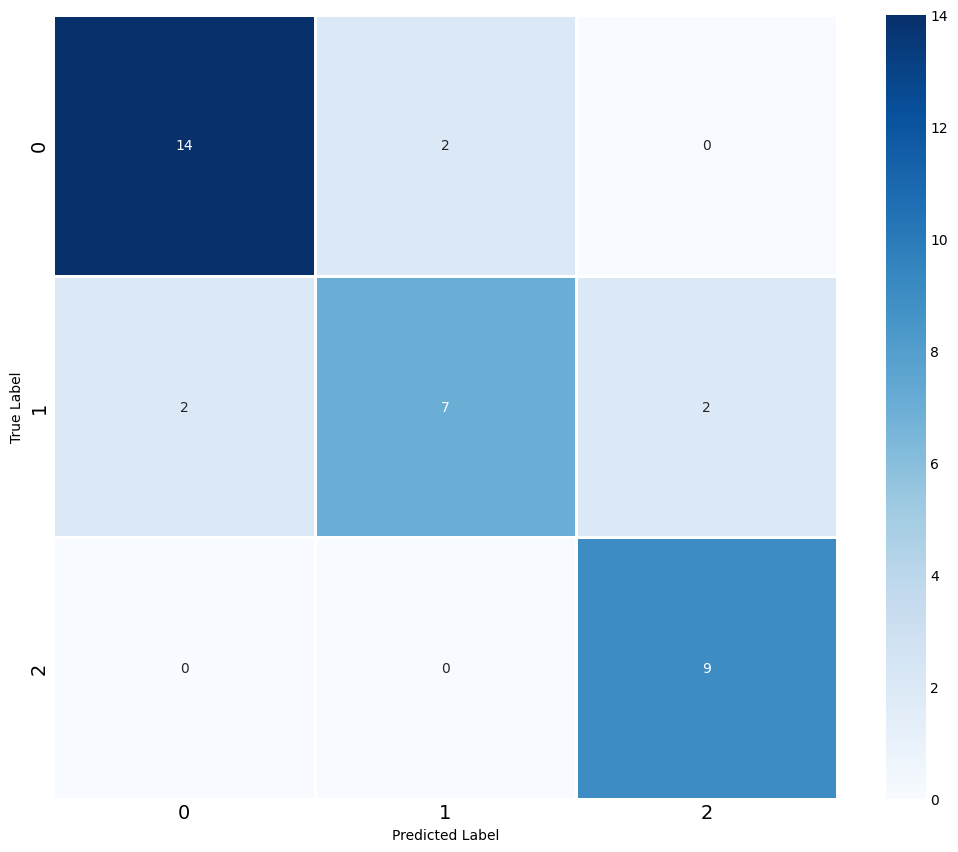

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

with plt.style.context(plt.style.available[2]): #选择一个可用样式
    plt.figure(figsize=(10, 8), dpi=100)
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', edgecolor='white', lw=1, square=True)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()

In [13]:
# 决策树可视化
from sklearn import tree
# 导出决策树模型为文本格式
r = tree.export_text(clf, feature_names=list(data.iloc[:, :-1].columns))
print(r)



|--- proline <= 755.00
|   |--- flavanoids <= 1.40
|   |   |--- color_intensity <= 3.56
|   |   |   |--- class: 1
|   |   |--- color_intensity >  3.56
|   |   |   |--- class: 2
|   |--- flavanoids >  1.40
|   |   |--- magnesium <= 121.00
|   |   |   |--- class: 1
|   |   |--- magnesium >  121.00
|   |   |   |--- class: 2
|--- proline >  755.00
|   |--- flavanoids <= 2.25
|   |   |--- flavanoids <= 0.90
|   |   |   |--- class: 2
|   |   |--- flavanoids >  0.90
|   |   |   |--- class: 1
|   |--- flavanoids >  2.25
|   |   |--- class: 0



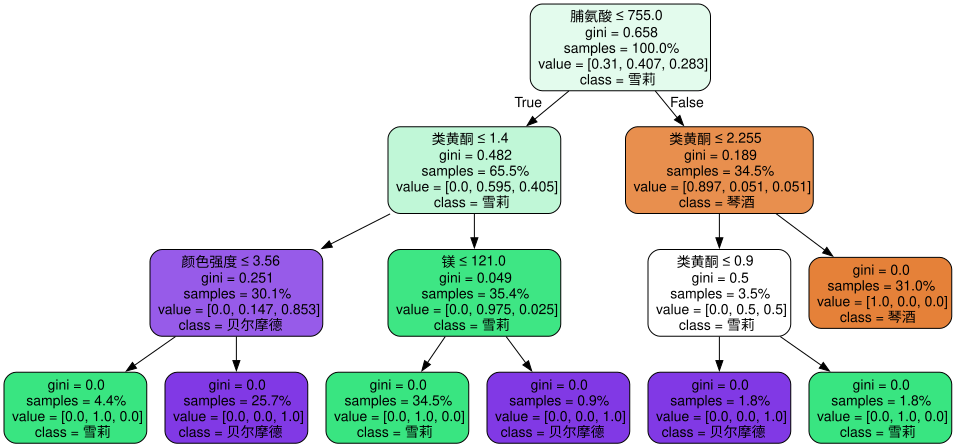

In [14]:
from sklearn import tree
import graphviz # pip install

feature_name = ['酒精', '苹果酸', '灰', '灰的碱性', '镁', '总酚', '类黄酮', '非类黄酮类', '花青素', '颜色强度', '色调', 'od280/od315稀释葡萄酒', '脯氨酸'] # 假设这些是特征名称
dot = tree.export_graphviz(clf,
                           feature_names=feature_name, # 特征的名称列表
                           class_names=["琴酒", "雪莉", "贝尔摩德"], # 分类的名称
                           filled=True, # 让节点填充颜色
                           rounded=True, # 让节点边框圆角
                           proportion=True, # 是否为显示类别的比例信息
                           special_characters=True # 特殊字符
                           )

# graphviz.Source(dot).render('dtree_visual',format='pdf') #将输出保存为pdf文件
graphviz.Source(dot) #在notebook中显示

In [15]:
import dtreeviz
viz_model = dtreeviz.model(clf,
                           X_train=X_train,
                           y_train=y_train,
                           feature_names=feature_name,
)

这段代码是 dtreeviz 库中 model 函数的参数说明,该函数用于创建一个模型适配器,以便为不同的决策树库提供一
致的接口。下面是这个函数的中文参数说明:

· model:一个来自支持的决策树库的基于树的模型,例如sklearn、XGBoost和TensorFlow。

· X_train:用于训练模型的特征;一个形状为(n_samples,n_features)的二维数组或类似对象。

· y_train:用于训练模型的分类器或回归器目标;一个形状为(n_samples,1)的一维数组或类似对象。

· tree_index:如果模型是一个由多棵树组成的集成模型(如随机森林),则为树的索引(从0开始)。

· feature_names:特征名称列表,顺序应与 X_train 中的特征顺序相同。

· target_name:目标变量的名称(字符串);例如,对于房价回归器,这可能是"price”。

· class_names:对于分类器,与标签相关联的名称是什么?可以是一个字符串列表或一个将整数映射到字符串的映
射。

· return:返回一个 DTreeVizAPI 对象,该对象提供了 dtreeviz
回对象上调用 view()方法在笔记本中显示它。

这个函数的主要作用是将不同的决策树模型适配到dtreeviz 库中,以便可以使用 dtreeviz 提供的各种可视化和解释方法。

d:\conda_envs\syc\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


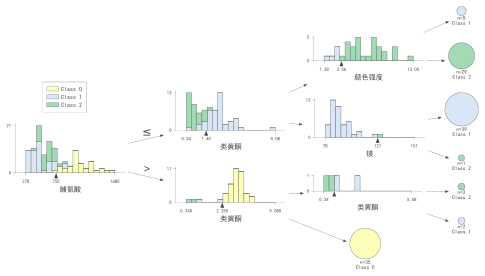

In [16]:
import logging
import warnings
import matplotlib.pyplot as plt
# 屏蔽Matplotlib的警告信息
logging.getLogger('matplotlib').setLevel(logging.ERROR)
#屏蔽 warnings 警告信息
warnings.filterwarnings("ignore", message=".*Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated.*")
warnings.filterwarnings("ignore", message=".*The 'n_features_' attribute was deprecated in scikit-learn 1.2 and will be removed in 1.4.*")
# 屏蔽pandas的警告信息
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
#要使用默认可视化显示决策树
plt.rcParams['font.sans-serif'] = 'SimHei'  # 用来正常显示中文标签
viz_model.view(scale=0.8,
               fontname="SimHei",
               orientation='LR' # 决策树的方向:从左到右)
)

d:\conda_envs\syc\Lib\site-packages\dtreeviz\models\shadow_decision_tree.py:335: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
d:\conda_envs\syc\Lib\site-packages\dtreeviz\trees.py:1231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
d:\conda_envs\syc\Lib\site-packages\dtreeviz\trees.py:420: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


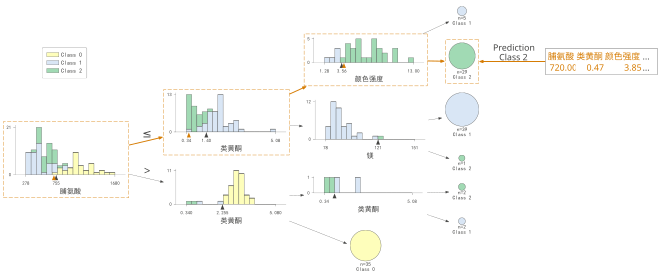

In [17]:
# 预测路径的使用
import logging
import matplotlib.pyplot as plt
#获取核心日志
#这个记录器负责产生顽固的提示
mpl_logger = logging.getLogger('matplotlib')
#将日志级别提升到ERROR
mpl_logger.setLevel(logging.ERROR)
x = X_train.iloc[19].copy()
# 现在运行预测路径可视化
viz = viz_model.view(x=x, fontname="SimHei", orientation='LR', scale=0.8)
#显示图像
viz

In [18]:
import cairosvg
import os

# 1. 中城图像对象并赋值给变量'v'
# 注意:这里需要把你之前view的参数都带上
v = viz_model. view(x=x, fontname='simhei', show_just_path=True)

# 2. 将SVG 文件保存到本地(这一步是必须的,否则后面读不到文件)
v.save("dtree.svg")

# 确认一下文件是否真的存在了
if os.path.exists("dtree.svg"):
    print("SVG 文件保存成功,正在转换.")

# 3. 读取刚刚保存的SVG 文件
    with open('dtree.svg','rb')as f: #建议用'rb’二进制读取
                svg_bytes = f.read()
            # 4. 转换为PDF
    try:

            cairosvg.svg2pdf(bytestring=svg_bytes, write_to='tree.pdf' )
            print('成功保存:tree.pdf')
    except Exception as e:
            print(f"PDF转换失败:{e}")

            # 5. 转换为PNG
    try:
            cairosvg.svg2png(bytestring=svg_bytes, write_to='tree.png', scale=2, dpi=200)
            print("成功保存:tree.png")
    except Exception as e:
            print(f"PNG 转换失败:{e}")

else:
    print("错误:SVG 文件未生成。")


SVG 文件保存成功,正在转换.
成功保存:tree.pdf
成功保存:tree.png


In [19]:
# 决策树调参
# 创建决策树分类器实列,使用基尼不纯度作为分裂标准
clf = DecisionTreeClassifier(criterion='gini')
#使用训练数据拟合模型
clf.fit(X_train, y_train)
#计算训练集合准确度
train_score = clf.score(X_train, y_train)
#计算测试集的准确度
test_score = clf.score(X_test, y_test)
#计算验证集的准确度
val_score = clf.score(X_val, y_val)
#打印结果
print(f"训练集准确度: {train_score:.4f}")
print(f"测试集准确度: {test_score:.4f}")    

训练集准确度: 1.0000
测试集准确度: 0.8889


测试集最大分数0.8611111111111112，训练集最大分数1.0


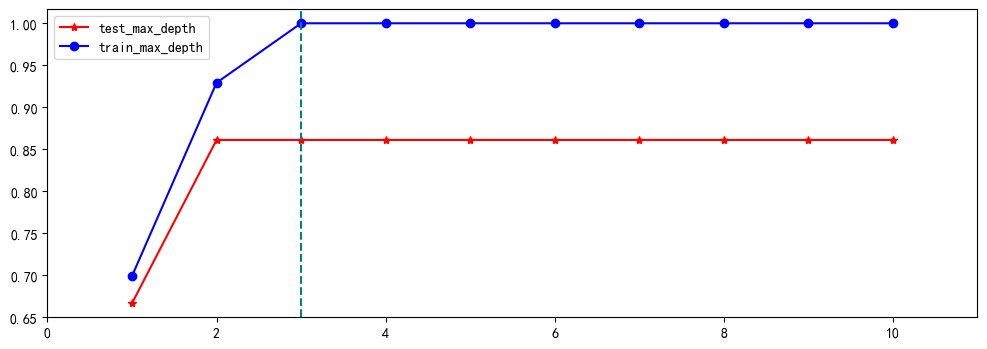

In [20]:
import matplotlib.pyplot as plt
from sklearn import tree

# Assuming X_train, y_train, X_test, y_test are already defined

plt.figure(figsize=(12, 4))
test = []  # List to store test set scores
train = []  # List to store train set scores

# Iterate through max_depth from 1 to 10 (inclusive)
for i in range(1, 11):
    # Initialize a Decision Tree Classifier
    clf = tree.DecisionTreeClassifier(max_depth=i,  # Maximum depth of the tree
                                      criterion='gini',  # Splitting criterion, Gini impurity
                                      random_state=30,  # Random seed for reproducibility
                                      splitter='best')  # Strategy for choosing the split at each node

    # Train the model on the training data
    clf.fit(X_train, y_train)

    # Calculate scores on training and testing data
    score1 = clf.score(X_train, y_train)  # Score on training set
    score2 = clf.score(X_test, y_test)  # Score on testing set

    # Append the scores to their respective lists
    test.append(score2)
    train.append(score1)

# Plot the scores against max_depth
# x-axis: max_depth from 1 to 10, y-axis: score
plt.plot(range(1, 11), test, color='red', label="test_max_depth", marker='*')
plt.plot(range(1, 11), train, color='blue', label="train_max_depth", marker='o')

plt.xlim(0, 11)  # Set the range for the x-axis
plt.axvline(x=3, color='teal', linestyle='--')  # Add a vertical reference line at x=3
plt.legend()  # Display the legend

# Print the maximum scores for both sets
print(f"测试集最大分数{max(test)}，训练集最大分数{max(train)}")

plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap

# Grid search
param_grid = {
    'max_depth': list(range(3, 5)),  # 树的最大深度，防止过拟合
    'min_samples_split': list(range(3, 10, 1)), # 节点分裂的最小样本数，候选项值3-9(节点样本数≥该值才允许分裂，避免分裂出样本量过少的节点)
    'min_samples_leaf': list(range(2, 5)), # 一个叶子节点至少包含多少个数据才可以划分
    'max_leaf_nodes': list(range(2, 5)), # 限制树的叶子节点数，简化模型
    'splitter': ['best', 'random'], # 节点分裂策略：候选项值best（优先最优分裂点）, random（随机选择分裂点）
    'criterion': ['gini', 'entropy'], # 节点纯度衡量标准：候选项值gini（基尼系数）、entropy（信息熵）
    'ccp_alpha': [0.0, 0.1, 0.5] # 剪枝系数：候选项值为0（不剪枝）0.1、0.5（值越大剪枝越彻底，缓解过拟合）
}
%time
tree = DecisionTreeClassifier()

gs = GridSearchCV(estimator=tree,
                  param_grid=param_grid,
                  scoring='f1_micro',
                  n_jobs=-1,
                  verbose=1)

gs.fit(X_train, y_train)




CPU times: total: 0 ns
Wall time: 4.05 μs
Fitting 5 folds for each of 1512 candidates, totalling 7560 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'ccp_alpha': [0.0, 0.1, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 4], 'max_leaf_nodes': [2, 3, ...], ...}"
,scoring,'f1_micro'
,n_jobs,-1
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [ ]:
GridSearchCV(estimator=DecisionTreeClassifier(), n_jobs =-1, #并行计算使用所有CPU
            param_grid={'ccp_alpha':[0.0,0.1,0.5],#剪枝系数
            'criterion': ['gini', 'entropy'],
            'max_depth': [3, 4],
            'max_leaf_nodes': [2, 3, 4],
            'min_samples_leaf': [5,6,7,8,9,10,11,14],
            'min_samples_split':[3,4,5,6,7,8,9],#节点分裂最小样本数:样本不足则不分裂
            'splitter':['best','random']},#分裂策略:优先最优分裂点/随机分裂点
            scoring='f1_micro',verbose=1)#微平均F1是先计算所有样本的精确率(P)和召回率(R),再求F1,对样
            # 最好的参数列表
gs.best_params_

{'ccp_alpha': 0.0,
 'criterion': 'gini',
 'max_depth': 4,
 'max_leaf_nodes': 4,
 'min_samples_leaf': 2,
 'min_samples_split': 9,
 'splitter': 'random'}

In [27]:
gs.best_score_  #最好的分数

np.float64(0.9122529644268773)

In [28]:
best_params = {
'ccp_alpha': 0.0,
'criterion': 'gini',
'max_depth': 3,
'max_leaf_nodes': 4,
'min_samples_leaf': 5,
'min_samples_split': 9,
'splitter': 'best'
}
dt = DecisionTreeClassifier(ccp_alpha=best_params['ccp_alpha'],
criterion=best_params['criterion' ],
max_depth=best_params['max_depth' ],
max_leaf_nodes=best_params['max_leaf_nodes'],
min_samples_leaf=best_params['min_samples_leaf'],
min_samples_split=best_params['min_samples_split'],
splitter=best_params['splitter' ])



dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,9
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,4
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
# 模型评估
from sklearn.metrics import accuracy_score
y_pred = dt.predict(X_test)
accuracy_score(y_test, y_pred)

0.8611111111111112

In [31]:
y_pred = dt.predict(X_test)
accuracy_score(y_test, y_pred)

0.8611111111111112

d:\conda_envs\syc\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.


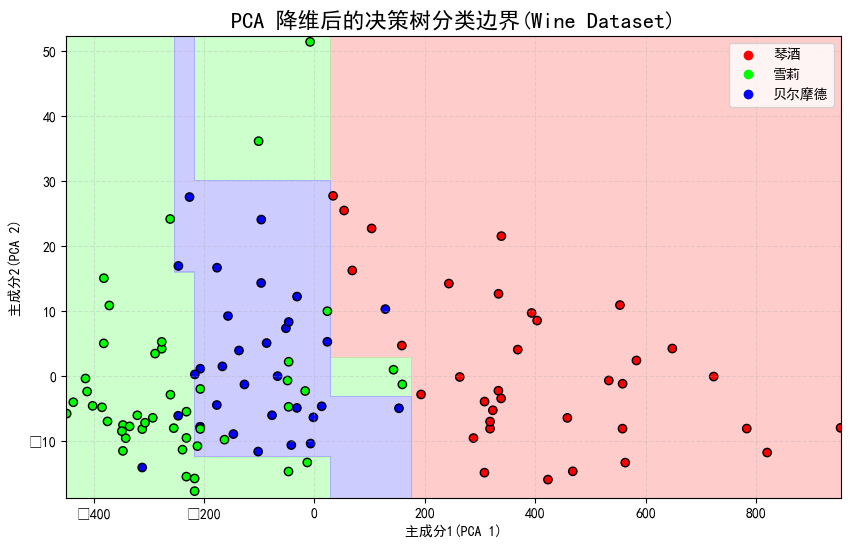

前两个主成分解释的方差比例:[0.99844214 0.00139593]
总信息保留率:99.98%


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap

# --- 1. 确保y是整数类型 ---
#如果y 是fLoat 类型(如0.0,1.0),分类器就会报错,必须转为int
y_train = y_train.astype(int)

# --- 2. 准备颜色映射
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# --- 3. 使用PCA 将13 维数据降到2 维 ---
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# --- 4. 在降维后的数据上训练模型-
#注意:这里为了画图而训练的一个新模型,仅使用2个主成分特征
dt_pca = DecisionTreeClassifier(max_depth=4, criterion='gini')
dt_pca.fit(X_train_pca,y_train)

# --- 5. 绘制边界 ---
# 创建网格
#计算PCA降维后训练集第一维特征的最小值和最大值,并向外扩展1个单位
#用于构建后续决策边界可视化的x轴范围(扩展是为了让边界不紧贴数据点,图表更美观)
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() +1
#计算PCA降维后训练集第二维特征的最小值和最大值,并向外扩展1个单位
# 用于构建后续决策边界可视化的y轴范围(扩展逻辑同上)
y_min, y_max =X_train_pca[:,1].min() -1,X_train_pca[:,1].max() +1
xx, yy =np.meshgrid(np.arange(x_min, x_max, 0.05),#步长0.05,越小越平滑
np.arange(y_min, y_max, 0.05))
# 预测网格中每个点的类别
Z= dt_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 开始绘图
plt.figure(figsize=(10, 6))

# 画背景色块
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

# 西训练样本点
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k')

plt.xlabel("主成分1(PCA 1)")
plt.ylabel("主成分2(PCA 2)")
plt.title("PCA 降维后的决策树分类边界(Wine Dataset)",fontsize=16)

# 添加图例
plt.legend(handles=scatter.legend_elements()[0], labels=["琴酒","雪莉","贝尔摩德"])
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

#打印PCA 保留了多少原始信息
print(f"前两个主成分解释的方差比例:{pca.explained_variance_ratio_}")
print(f"总信息保留率:{sum(pca.explained_variance_ratio_) :.2%}")

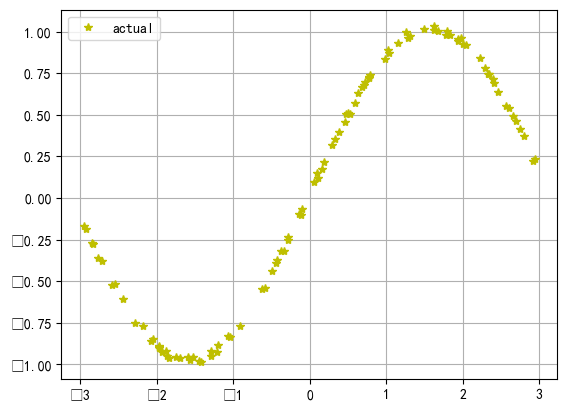

In [35]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

N = 100
x = np. random.rand(N) * 6 - 3
y = np.sin(x) + np.random.rand(N) * 0.05
x = x.reshape(-1, 1)

plt.plot(x, y, "y*", label="actual")
plt.legend(loc="upper left")
plt.grid()
plt. show()

d:\conda_envs\syc\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.


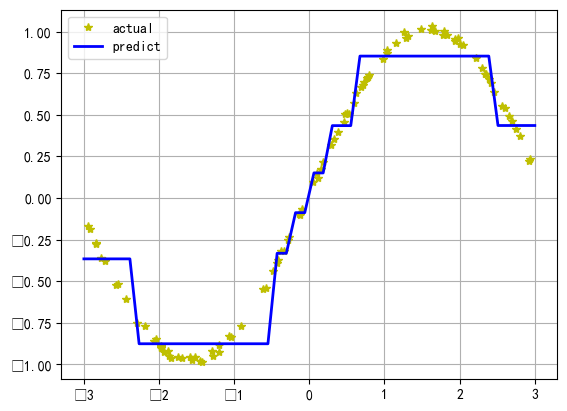

In [36]:
dt_reg = DecisionTreeRegressor(criterion='friedman_mse', max_depth=3)
dt_reg.fit(x, y)
x_test = np.linspace(-3, 3, 50).reshape(-1, 1)
y_hat = dt_reg. predict(x_test)
plt.plot(x, y, "y*", label="actual")
plt.plot(x_test, y_hat, "b-", linewidth=2, label="predict")
plt.legend(loc="upper left")
plt.grid()
plt.show()

d:\conda_envs\syc\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.


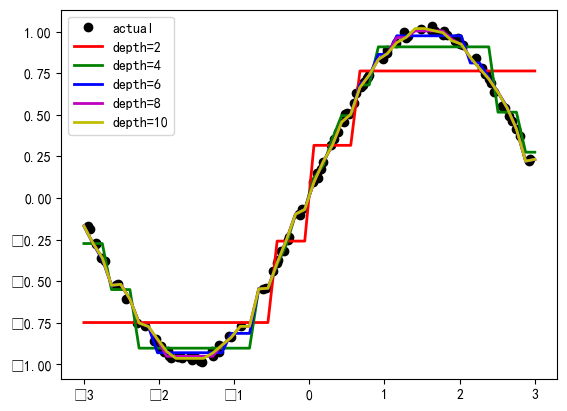

In [38]:
# 比较不同深度的决策树
depth = [2, 4, 6, 8, 10]
color = 'rgbmy'
dt_reg = DecisionTreeRegressor()
plt.plot(x, y, "ko", label="actual")
x_test = np.linspace(-3, 3, 50).reshape(-1, 1)
for d, c in zip(depth, color):
    dt_reg.set_params(max_depth=d)
    dt_reg.fit(x, y)
    y_hat = dt_reg.predict(x_test)
    plt.plot(x_test, y_hat, '-', color=c, linewidth=2, label="depth=%d" %d)
plt.legend(loc="upper left")
plt. show()

# 据册数回归案例：非线性时序预测

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')  # 忽略无关警告
# 中文显示适配（<bos>, 避免乱码）
plt.rc('font', family='SimHei')
plt.rc('axes', unicode_minus=False)

# 1. 生成时间序列 (365 天x24小时=8760 个时序样本, 高样本量增加)
date_range = pd.date_range(start='2024-01-01', end='2024-12-31 23:00:00', freq='H')
df = pd.DataFrame(index=date_range, columns=['负荷_真实值'])
# 构造非线性目标变量 (电力负荷): 融合多个周期+趋势+噪声, 模拟真实波动
np.random.seed(30)  # 固定随机种子, 结果可复现
time_idx = np.arange(len(df))  # 时间序列索引(0~8759)
df['负荷_真实值'] = (
    100 + 30 * np.sin(2 * np.pi * time_idx / 24)  # 日周期 (24小时波动, 白天高、夜间低) + 周周期 (工作日高、周末低)
    + 15 * np.where(df.index.weekday < 5, 1, 0.6)  # 周周期 (工作日负荷高20%)
    + 25 * np.sin(2 * np.pi * time_idx / (365 * 24))  # 季性趋势 (夏季高/冬季低, 春秋低)
    + 5 * np.random.randn(len(df))  # 随机噪声 (增加预测难度)
)

# 3. 特征工程 (核心: 多维度时序特征, 提升模拟预测能力)
## 3.1 时序滞后特征 (历史滞后特征, 滞后1~24小时, 捕捉趋势)
for lag in [1, 3, 6, 12, 24]:
    df[f'负荷_滞后{lag}h'] = df['负荷_真实值'].shift(lag)  # 滞后特征
## 3.2 滑动统计特征 (捕捉局部波动趋势, 增加特征维度)
df['负荷_24h均值'] = df['负荷_真实值'].rolling(window=24).mean()  # 24小时滑动平均
df['负荷_12h标准差'] = df['负荷_真实值'].rolling(window=12).std()  # 12小时滑动标准差
df['负荷_24h最大值'] = df['负荷_真实值'].rolling(window=24).max()  # 24小时滑动最大值

## 3.3 时间编码 (将时间维度转化为模型可识别的数值特征)
df['小时'] = df.index.hour  # 小时 (0~23)
df['星期'] = df.index.weekday  # 星期 (0=周一~6=周日)
df['月份'] = df.index.month  # 月份 (1~12)
df['是否工作日'] = np.where(df.index.weekday < 5, 1, 0)  # 二元特征: 1=工作日, 0=周末

## 3.4 外部影响特征 (模拟温度对负荷的实时影响, 非线性关联)
df['温度'] = 15 + 10 * np.sin(2 * np.pi * time_idx / (365 * 24)) + 8 * np.random.randn(len(df))
df['温度_符合交互'] = df['温度'] * df['负荷_滞后1h']  # 交互特征: 捕捉温度与历史负荷的联合影响

# 4. 处理缺失值 (滑动/滞后特征会产生缺失, 直接删除, 保证数据完整性)
df = df.dropna()

# 5. 时序序列划分 (严禁随机划分! 按时间顺序拆分, 避免数据泄露)
split_idx = int(len(df) * 0.8)  # 80% 训练集, 20% 测试集
X_train, X_test = df.iloc[:split_idx, 1:], df.iloc[split_idx:, 1:]
y_train, y_test = df.iloc[:split_idx, 0], df.iloc[split_idx:, 0]

# 6. 特征标准化 (化时序特征数值范围差异大, 标准化提升模型稳定性)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 训练集特征标准化
X_test_scaled = scaler.transform(X_test)  # 测试集仅用训练集结果转换

print(f"训练集样本量: {len(X_train)}, 特征数: {X_train.shape[1]}")
print(f"测试集样本量: {len(X_test)}, 特征数: {X_test.shape[1]}")

# 3. 超参数优化 (网络搜索+时序交叉验证, 避免拟合)
# 使用TimeSeriesSplit替代普通交叉验证 (适配时序数据, 避免未来数据泄露)
# 超参网格涵盖 CTP数, 结构参数、分割参数, 全面优化模型
# 并行计算提升效率, 同时指定回归专用评估指标 (RMSE)
# 1. 定义超参数网格 (高维度组合, 覆盖决策树核心参数, 兼顾拟合、过拟合)
param_grid = {
    'max_depth': [6, 8, 10, 12],  # 树的最大深度: 过深易过拟合
    'min_samples_split': [5, 10, 15, 20],  # 节点分裂最小样本数: 节点分裂最小样本数
    'min_samples_leaf': [3, 5, 8, 10],  # 叶子节点最小样本: 叶子节点最小样本, 缓解过拟合
    'max_leaf_nodes': [30, 50, 80, None],  # 最大叶子数, Nnne 表示不限制
    'splitter': ['best', 'random'],  # 分裂策略
    'ccp_alpha': [0.0, 0.01, 0.05, 0.1],  # 剪枝系数: 值越大越剪枝
    'min_weight_fraction_leaf': [0.0, 0.01, 0.02]  # 叶子节点的权重占比: 适配非均衡样本
}

# 2. 初始化决策树回归器 (基模)
dt_reg = DecisionTreeRegressor(random_state=30)

# 3. 时序交叉验证 (TimeSeriesSplit): 按时间顺序拆分, 符合真实预测场景 (无未来数据泄露)
tscv = TimeSeriesSplit(n_splits=5)  # 5折时序交叉验证

# 4. 网络搜索 (GridSearchCV): 遍历超参组合, 找到最优模型
grid_search = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid,
    cv=tscv,  # 使用时序交叉验证
    scoring='neg_mean_squared_error',  # 回归评价指标: 默认最大化得分
    n_jobs=-1,  # 并行计算: 使用所有CPU核心, 提升搜索速度
    verbose=1,  # 打印搜索日志
    refit=True,  # 搜索完成后, 用最优参数重新拟合全局训练集
)

# 5. 执行网格搜索 (训练过程, 高样本量+多棵树组合, 耗时略长)
grid_search.fit(X_train_scaled, y_train)

# 6. 输出最优超参数组合:
print(f"\n最优超参数组合: {grid_search.best_params_}")
best_dt_reg = grid_search.best_estimator_  # 获取最优模型

# 4. 模型训练与深度评估 (多指标+可视化, 诊断模型性能)
# 用RMSE, MAE, R^2三个指标全面评估 (RMSE敏感度异常值, R^2反映拟合优度)
# 可视化预测值vs真实值 (直观观察拟合效果)、残差分布 (判断误差是否随机, 无系统偏差)
# 分析特征重要性 (识别关键影响因素, 解释模型逻辑)

# 1. 模型预测 (训练集+测试集, 对比泛化能力)
y_train_pred = best_dt_reg.predict(X_train_scaled)
y_test_pred = best_dt_reg.predict(X_test_scaled)

# 2. 多指标评估 (回归专用指标, 全面反映模型性能)
def reg_evaluate(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # RMSE
    mae = mean_absolute_error(y_true, y_pred)  # 平均绝对误差 (与目标变量同量级, 直观)
    r2 = r2_score(y_true, y_pred)  # 决定系数(R^2 0~1, 越接近1越好) (抗异质能力强)
    print(f"\n{set_name}集评估结果:")
    print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R^2: {r2:.4f}")
    return rmse, mae, r2

训练集样本量: 7008, 特征数: 14
测试集样本量: 1752, 特征数: 14
Fitting 5 folds for each of 6144 candidates, totalling 30720 fits

最优超参数组合: {'ccp_alpha': 0.01, 'max_depth': 8, 'max_leaf_nodes': None, 'min_samples_leaf': 5, 'min_samples_split': 15, 'min_weight_fraction_leaf': 0.0, 'splitter': 'best'}



训练集评估结果:
RMSE: 5.34, MAE: 4.22, R^2: 0.9647

测试集评估结果:
RMSE: 6.74, MAE: 5.37, R^2: 0.9137


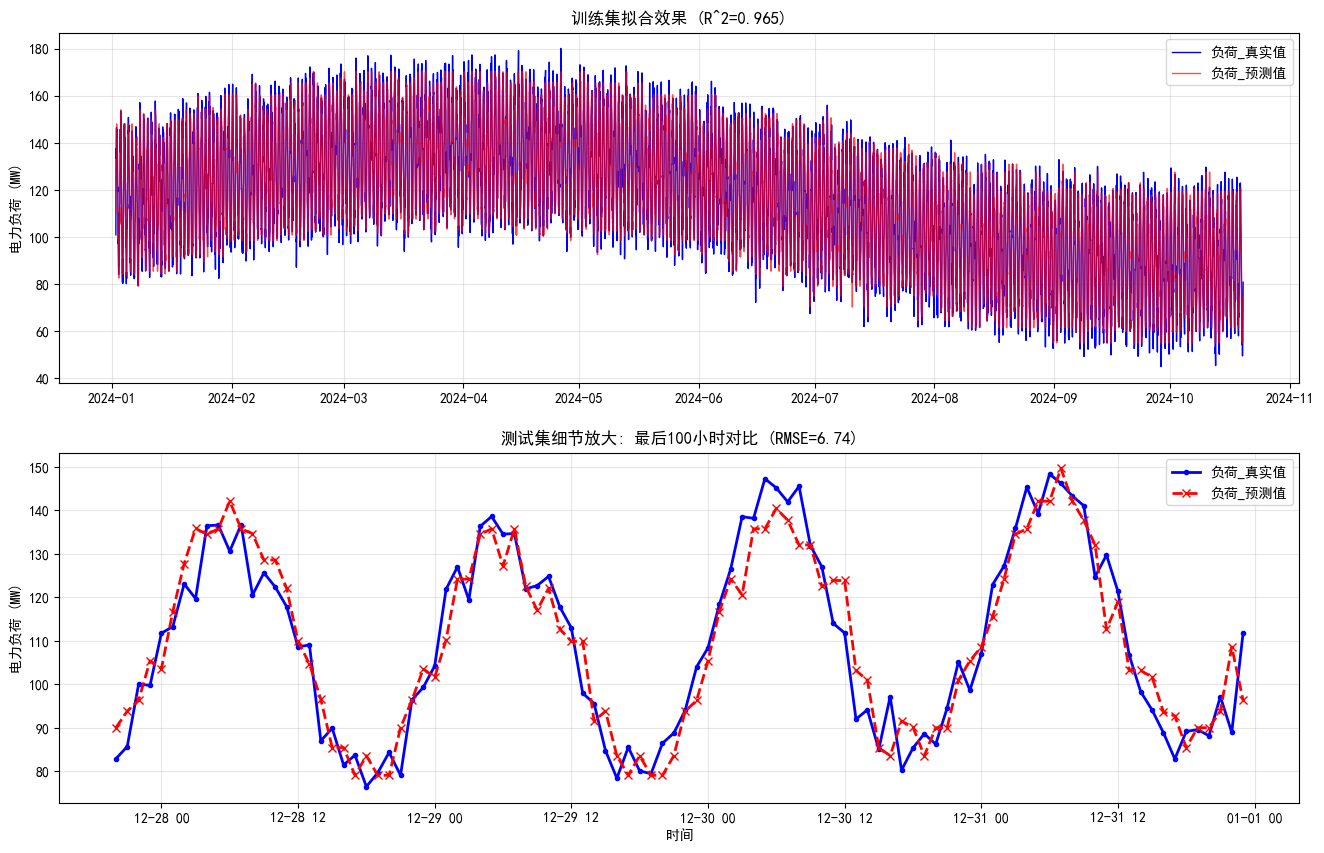

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. 模型预测 (修正变量名拼写错误)
# 假设之前的模型变量名为 best_dt_reg (根据上一段代码)
# 假设特征变量名为 X_train_scaled, X_test_scaled (通常大写X)
y_train_pred = best_dt_reg.predict(X_train_scaled) 
y_test_pred = best_dt_reg.predict(X_test_scaled)   # 统一变量名为 y_test_pred

# 2. 多指标评估函数
def reg_evaluate(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # 修正 f-string 格式: {rmse :. 2f} 中间不能有空格，应为 {rmse:.2f}
    print(f"\n{set_name}集评估结果:")
    print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R^2: {r2:.4f}")
    return rmse, mae, r2

# 执行评估 (修正字符串输入乱码)
train_rmse, train_mae, train_r2 = reg_evaluate(y_train, y_train_pred, "训练")
test_rmse, test_mae, test_r2 = reg_evaluate(y_test, y_test_pred, "测试")

# 3. 可视化: 预测值 vs 真实值
plt.figure(figsize=(16, 10)) #稍微调高一点高度

# 子图1: 训练集 (全量展示可能太密，主要看趋势)
plt.subplot(2, 1, 1)
plt.plot(y_train.index, y_train, color='blue', label='负荷_真实值', linewidth=1)
plt.plot(y_train.index, y_train_pred, color='red', label='负荷_预测值', linewidth=1, alpha=0.7)
plt.title(f'训练集拟合效果 (R^2={train_r2:.3f})', fontsize=12)
plt.ylabel('电力负荷 (MW)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

# 子图2: 测试集 (截取最后100小时展示细节)
plt.subplot(2, 1, 2)
# 确保索引切片对齐
test_idx = y_test.index[-100:]      # 时间索引
y_test_true_plot = y_test.values[-100:]    # 真实值
y_test_pred_plot = y_test_pred[-100:]      # 预测值

plt.plot(test_idx, y_test_true_plot, color='blue', label='负荷_真实值', linewidth=2, marker='.')
plt.plot(test_idx, y_test_pred_plot, color='red', label='负荷_预测值', linewidth=2, linestyle='--', marker='x')
plt.title(f'测试集细节放大: 最后100小时对比 (RMSE={test_rmse:.2f})', fontsize=12)
plt.xlabel('时间', fontsize=10)
plt.ylabel('电力负荷 (MW)', fontsize=10)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

训练集样本量: 7027, 特征数: 5
测试集样本量: 1757, 特征数: 5

==================== 决策树网格搜索 ====================

==================== 随机森林网格搜索 ====================

========================= 最优参数结果 =========================
决策树最优参数:{'ccp_alpha': 0.0, 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 10}
随机森林最优参数:{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}

--------------- 决策树 评估结果 ---------------
训练集: RMSE =4.46, MAE=3.54, R2=0.9753
测试集: RMSE =13.97, MAE=11.52, R2=0.6308

--------------- 随机森林 评估结果 ---------------
训练集: RMSE =4.54, MAE=3.62, R2=0.9743
测试集: RMSE =14.37, MAE=11.97, R2=0.6091


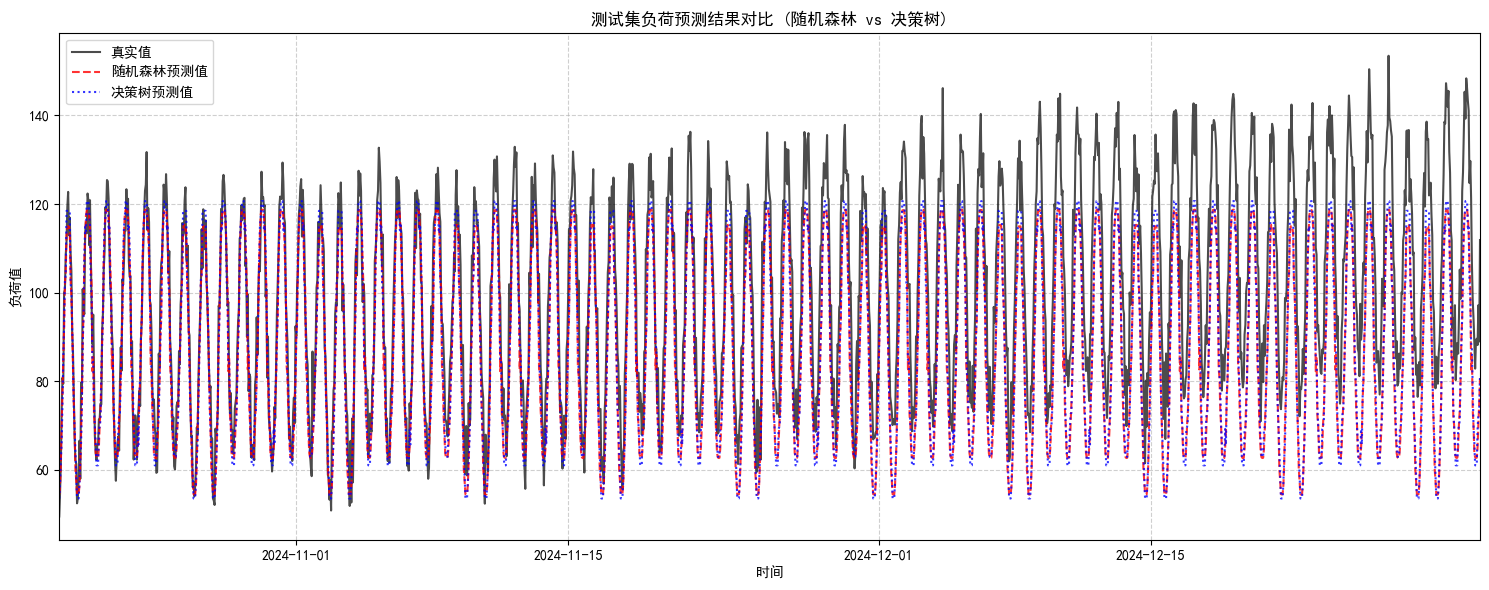

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from sklearn.inspection import PartialDependenceDisplay # 暂时不需要，保持代码整洁

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# ================================== 1. 数据准备与特征工程 ==================================
# 生成时间索引 (365天X24小时)
date_range = pd.date_range(start='2024-01-01', end='2024-12-31 23:00:00', freq='H')
df = pd.DataFrame(index=date_range)

# 构造目标变量
np.random.seed(30)
time_idx = np.arange(len(df))
df['负荷_真实值'] = (
    100 + 30 * np.sin(2 * np.pi * time_idx / 24)  # 日周期
    + 15 * np.where(df.index.weekday < 5, 1, 0.6) # 周效应
    + 25 * np.sin(2 * np.pi * time_idx / (365 * 24)) # 年趋势
    + 5 * np.random.randn(len(df)) # 噪声
)

# 关键优化：从时间索引中提取时序特征
df['小时'] = df.index.hour
df['星期几'] = df.index.dayofweek
df['月份'] = df.index.month
df['季度'] = df.index.quarter
df['年天'] = df.index.dayofyear # 用于捕捉更精细的季节性/趋势

# 数据划分
y = df['负荷_真实值']
X = df.drop('负荷_真实值', axis=1) # 现在 X 包含了所有特征

split_idx = int(len(df) * 0.8)

# 时序划分 (严禁随机划分)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"训练集样本量: {len(X_train)}, 特征数: {X_train.shape[1]}")
print(f"测试集样本量: {len(X_test)}, 特征数: {X_test.shape[1]}")

# ================================== 2. 超参数优化 (决策树+随机森林) ==================================
# 2.1 决策树超参数网格
dt_param_grid = {
    'max_depth': [8, 10, 12],
    'min_samples_split': [10, 15],
    'min_samples_leaf': [5, 8],
    'ccp_alpha': [0.0, 0.01]
}

# 2.2 随机森林超参数网格
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [8, 10],
    'min_samples_split': [10, 15],
}

# 时序交叉验证
tscv = TimeSeriesSplit(n_splits=5)

# 2.3 决策树网格搜索
print("\n" + "="*20 + " 决策树网格搜索 " + "="*20)
dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=30),
    param_grid=dt_param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0, # 降低输出信息
    refit=True
)
dt_grid.fit(X_train_scaled, y_train)
best_dt = dt_grid.best_estimator_

# 2,4 随机森林网格搜索
print("\n" + "="*20 + " 随机森林网格搜索 " + "="*20)
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=30),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0, # 降低输出信息
    refit=True
)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

# 输出最优参数
print("\n" + "="*25 + " 最优参数结果 " + "="*25)
print(f"决策树最优参数:{dt_grid.best_params_}")
print(f"随机森林最优参数:{rf_grid.best_params_}")

# ================================== 3. 模型评估 (多指标+可视化) ==================================
def reg_evaludate(model, X_train, y_train, X_test, y_test, model_name):
    """回归模型评估函数 (输出RMSE/MAE/R^2)"""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 计算指标
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # 打印效果
    print(f"\n{'-'*15} {model_name} 评估结果 {'-'*15}")
    print(f"训练集: RMSE ={train_rmse:.2f}, MAE={train_mae:.2f}, R2={train_r2:.4f}")
    print(f"测试集: RMSE ={test_rmse:.2f}, MAE={test_mae:.2f}, R2={test_r2:.4f}")

    # 返回预测值用于绘图
    return y_test_pred

# 评估并获取预测值
y_dt_pred = reg_evaludate(best_dt, X_train_scaled, y_train, X_test_scaled, y_test, "决策树")
y_rf_pred = reg_evaludate(best_rf, X_train_scaled, y_train, X_test_scaled, y_test, "随机森林")

# 3.1 可视化对比
plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test.values, label='真实值', color='black', alpha=0.7)
plt.plot(y_test.index, y_rf_pred, label='随机森林预测值', linestyle='--', color='red', alpha=0.8)
plt.plot(y_test.index, y_dt_pred, label='决策树预测值', linestyle=':', color='blue', alpha=0.8)

# 仅显示测试集上最后 5 天的数据，以更好地观察细节
# start_date = y_test.index[-5 * 24] # 如果数据足够多，可以这样聚焦
start_date = y_test.index[0] # 这里我们展示整个测试集
plt.xlim(start_date, y_test.index[-1])

plt.title('测试集负荷预测结果对比 (随机森林 vs 决策树)')
plt.xlabel('时间')
plt.ylabel('负荷值')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

训练集样本量: 7027, 特征数: 5
测试集样本量: 1757, 特征数: 5

========================= 最优参数结果 =========================
决策树最优参数:{'ccp_alpha': 0.0, 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 10}
随机森林最优参数:{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}

--------------- 决策树 评估结果 ---------------
训练集: RMSE =4.46, MAE=3.54, R2=0.9753
测试集: RMSE =13.97, MAE=11.52, R2=0.6308

--------------- 随机森林 评估结果 ---------------
训练集: RMSE =4.54, MAE=3.62, R2=0.9743
测试集: RMSE =14.37, MAE=11.97, R2=0.6091


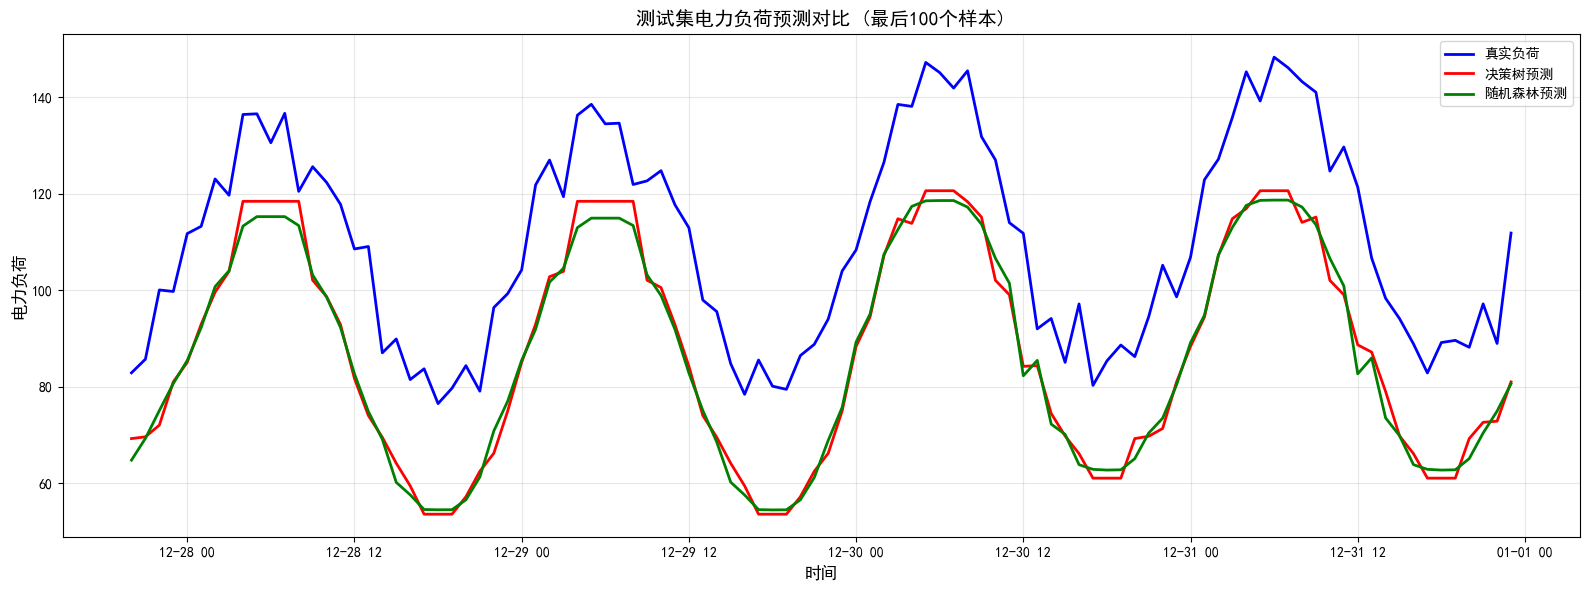

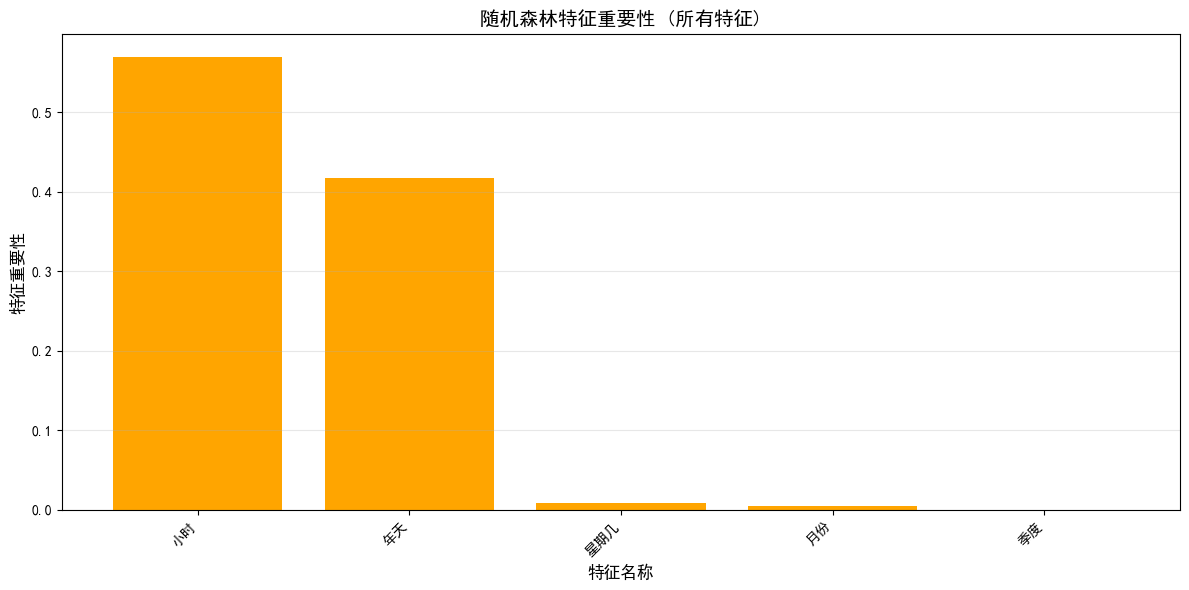


正在计算特征 '小时' 和 '星期几' 的交互偏依赖...


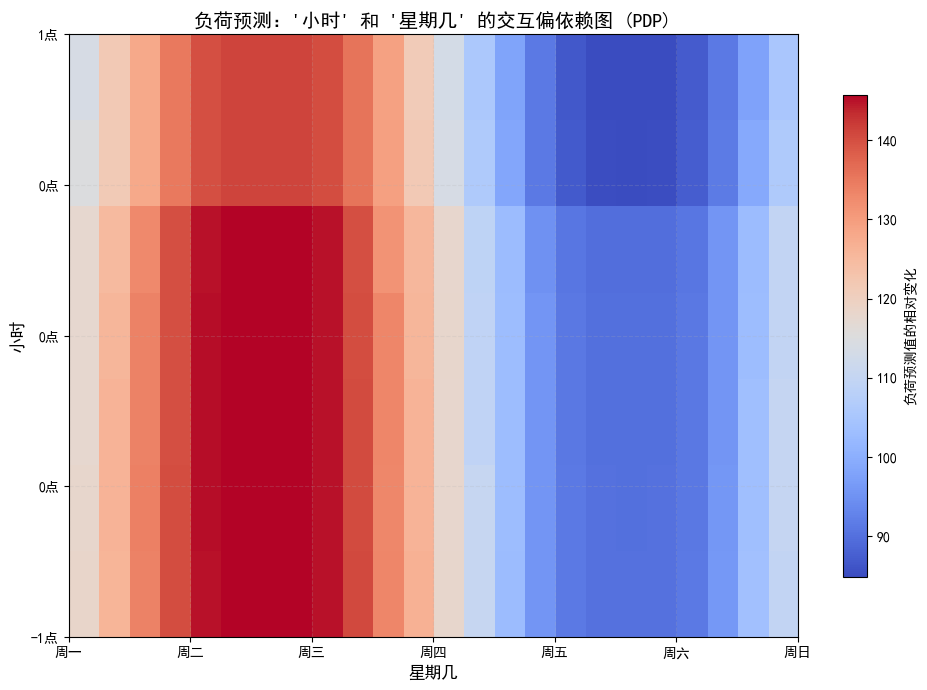

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay, partial_dependence # 导入PDP相关函数

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# ================================== 1. 数据准备与特征工程 (优化) ==================================
# 生成时间索引 (365天X24小时)
date_range = pd.date_range(start='2024-01-01', end='2024-12-31 23:00:00', freq='H')
df = pd.DataFrame(index=date_range)

# 构造目标变量
np.random.seed(30)
time_idx = np.arange(len(df))
df['负荷_真实值'] = (
    100 + 30 * np.sin(2 * np.pi * time_idx / 24)  # 日周期
    + 15 * np.where(df.index.weekday < 5, 1, 0.6) # 周效应 (工作日/周末)
    + 25 * np.sin(2 * np.pi * time_idx / (365 * 24)) # 年趋势
    + 5 * np.random.randn(len(df)) # 噪声
)

# 提取时序特征 (关键修复点)
df['小时'] = df.index.hour
df['星期几'] = df.index.dayofweek
df['月份'] = df.index.month
df['季度'] = df.index.quarter
df['年天'] = df.index.dayofyear

# 数据划分
y = df['负荷_真实值']
X = df.drop('负荷_真实值', axis=1) # 包含所有提取的特征

split_idx = int(len(df) * 0.8)

# 时序划分
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 将标准化后的数据转换回 DataFrame 以保留列名，便于后续特征重要性分析
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"训练集样本量: {len(X_train)}, 特征数: {X_train.shape[1]}")
print(f"测试集样本量: {len(X_test)}, 特征数: {X_test.shape[1]}")

# ================================== 2. 超参数优化 (运行) ==================================
dt_param_grid = {'max_depth': [8, 10, 12], 'min_samples_split': [10, 15], 'min_samples_leaf': [5, 8], 'ccp_alpha': [0.0, 0.01]}
rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [8, 10], 'min_samples_split': [10, 15]}
tscv = TimeSeriesSplit(n_splits=5)

# 决策树网格搜索
dt_grid = GridSearchCV(estimator=DecisionTreeRegressor(random_state=30), param_grid=dt_param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0, refit=True)
dt_grid.fit(X_train_scaled, y_train)
best_dt = dt_grid.best_estimator_

# 随机森林网格搜索
rf_grid = GridSearchCV(estimator=RandomForestRegressor(random_state=30), param_grid=rf_param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0, refit=True)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_ # 使用 best_rf 变量进行后续操作

print("\n" + "="*25 + " 最优参数结果 " + "="*25)
print(f"决策树最优参数:{dt_grid.best_params_}")
print(f"随机森林最优参数:{rf_grid.best_params_}")

# ================================== 3. 模型评估与可视化 (修复) ==================================
def reg_evaludate(model, X_train, y_train, X_test, y_test, model_name):
    """回归模型评估函数 (输出RMSE/MAE/R^2)"""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 计算指标
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # 打印效果
    print(f"\n{'-'*15} {model_name} 评估结果 {'-'*15}")
    print(f"训练集: RMSE ={train_rmse:.2f}, MAE={train_mae:.2f}, R2={train_r2:.4f}")
    print(f"测试集: RMSE ={test_rmse:.2f}, MAE={test_mae:.2f}, R2={test_r2:.4f}")

    return y_test_pred

# 评估并获取测试集预测值 (修复函数调用参数)
dt_test_pred = reg_evaludate(best_dt, X_train_scaled, y_train, X_test_scaled, y_test, "决策树")
rf_test_pred = reg_evaludate(best_rf, X_train_scaled, y_train, X_test_scaled, y_test, "随机森林")


# 3.1 预测值vs真实值对比 (最后100个测试样本)
plt.figure(figsize=(16, 6))
# 确保索引和数据对齐
test_idx = y_test.index[-100:]
y_test_true = y_test.loc[test_idx]

plt.plot(test_idx, y_test_true, label="真实负荷", linewidth=2, color="blue")
plt.plot(test_idx, dt_test_pred[-100:], label="决策树预测", linewidth=2, color="red")
plt.plot(test_idx, rf_test_pred[-100:], label="随机森林预测", linewidth=2, color="green")

plt.title("测试集电力负荷预测对比 (最后100个样本)", fontsize=14)
plt.xlabel("时间", fontsize=12)
plt.ylabel("电力负荷", fontsize=12)
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show() # 


# 3.2 特征重要性 (随机森林)
feature_importance = pd.DataFrame(
    {
        # 使用 X_train 的列名，以及 best_rf 的重要性
        "特征名称": X_train.columns, 
        "重要性": best_rf.feature_importances_, 
    }
).sort_values("重要性", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(feature_importance["特征名称"], feature_importance["重要性"], color="orange")
plt.xlabel("特征名称", fontsize=12)
plt.ylabel("特征重要性", fontsize=12)
plt.title("随机森林特征重要性 (所有特征)", fontsize=14)
# plt.gca().invert_yaxis() # 条形图默认是重要性高的在右边，不需要反转Y轴
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show() # 


# ================================== 4. 进阶：交互偏依赖图 (修复PDP特征) ==================================

# 获取特征在矩阵中的索引位置 (使用已有的 '小时' 和 '星期几' 进行交互分析)
feature_names = X_train.columns.tolist()
hour_idx = feature_names.index("小时")
weekday_idx = feature_names.index("星期几")

print("\n正在计算特征 '小时' 和 '星期几' 的交互偏依赖...")

# 1. 计算交互偏依赖 (使用 best_rf)
pdp_result = partial_dependence(
    best_rf,
    X=X_train_scaled, # 使用标准化后的数据
    features=[(hour_idx, weekday_idx)], # 交互特征组
    grid_resolution=30, # 降低分辨率以加快计算速度
    kind="average",
)

# 2. 提取sklearn 新版 Bunch 解结构
# Hour (0-23)
hour_grid_scaled = pdp_result["grid_values"][0] 
# Weekday (0-6)
weekday_grid_scaled = pdp_result["grid_values"][1] 

# 3. 计算相对变化 (减去均值)
pdp_values = pdp_result["average"][0].T # 转置以使小时在Y轴，星期几在X轴

plt.figure(figsize=(10, 7))

# 4. 绘制热力图
im = plt.imshow(
    pdp_values,
    extent=[
        weekday_grid_scaled.min(), weekday_grid_scaled.max(), 
        hour_grid_scaled.min(), hour_grid_scaled.max()
    ],
    aspect="auto",
    cmap="coolwarm",
    origin="lower", # 由于小时索引通常从小到大，使用 lower
)

# 5. 美化与标注
cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label("负荷预测值的相对变化", fontsize=10)

# 设置轴标签
# 由于 '小时' 和 '星期几' 是离散整数特征，我们可以使用原始的网格值作为刻度
# X 轴刻度 (星期几)
plt.xticks(
    ticks=np.linspace(weekday_grid_scaled.min(), weekday_grid_scaled.max(), len(weekday_grid_scaled)),
    labels=['周一', '周二', '周三', '周四', '周五', '周六', '周日']
)
# Y 轴刻度 (小时) - 只显示部分刻度
hour_labels = [f"{int(h)}点" for h in hour_grid_scaled]
plt.yticks(
    ticks=np.linspace(hour_grid_scaled.min(), hour_grid_scaled.max(), 5),
    labels=[hour_labels[i] for i in np.linspace(0, len(hour_labels)-1, 5, dtype=int)]
)

plt.xlabel("星期几", fontsize=12)
plt.ylabel("小时", fontsize=12)
plt.title("负荷预测：'小时' 和 '星期几' 的交互偏依赖图 (PDP)", fontsize=14)

plt.grid(alpha=0.2, linestyle="--")
plt.tight_layout()
plt.show() #

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus' ] = False

print("=" * 70)
print("代价复杂度剪枝(CCP)完整实现")
print("=" * 70)

# 1. 数据准备(葡萄酒分类,高维数据易过拟合,适合剪枝验证)
data = load_wine()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# 拆分验证集(用于选择最优剪枝子树)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"\n数据集划分:")
print(f"训练集:{len(X_train)}样本")
print(f"验证集:{len(X_val)}样本")
print(f"测试集:{len(X_test)}样本")
print(f"特征数:{X.shape[1]}")
print(f"类别数:{len(np.unique(y))}")




代价复杂度剪枝(CCP)完整实现

数据集划分:
训练集:99样本
验证集:25样本
测试集:54样本
特征数:13
类别数:3


# 剪枝决策树完整实现(代价复杂度剪枝CCP)

In [7]:
# 2. 训练”未剪枝的复杂决策树”(故意让其过拟合)
dt_unpruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    ccp_alpha=0.0,
    random_state=42
)

dt_unpruned.fit(X_train, y_train)

print("\n" + "=" * 70)
print("未剪枝树的性能")
print("=" * 70)
print(f"树深度:{dt_unpruned.get_depth()}")
print(f"叶子节点数:{dt_unpruned.get_n_leaves()}")
print(f"节点总数:{dt_unpruned.tree_.node_count}")
print(f"训练集准确率:{accuracy_score(y_train, dt_unpruned.predict(X_train)) :.4f}")
print(f"验证集准确率: {accuracy_score(y_val, dt_unpruned.predict(X_val)) :.4f}")
print(f"测试集准确率: {accuracy_score(y_test, dt_unpruned.predict(X_test)) :.4f}")

# 不限制深度(易过拟合)

# 初始不剪枝

plt.figure(figsize=(20, 10))


未剪枝树的性能
树深度:3
叶子节点数:4
节点总数:7
训练集准确率:1.0000
验证集准确率: 0.8000
测试集准确率: 0.9259


<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

# 计算CCP剪枝的序列


In [9]:
# 3. 计算CCP剪枝的 a 序列与子树
# sklearn自动计算所有可能的a_t,并生成对应的剪枝子树
print("\n" + "=" * 70)
print("计算 CCP 剪枝路径")
print("=" * 70)

path = dt_unpruned. cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas # 所有临界a值(从小到大)
# 对应的不纯度

print(f"找到{len(ccp_alphas)}个 alpha 值")
print(f"Alpha 范围:[{ccp_alphas.min() :.6f},{ccp_alphas.max() :.6f}]")

# 移除最后一个a(对应根节点,无意义)
ccp_alphas = ccp_alphas[ :- 1]

# 显示前10个aLpha值
print(f"\n前10个 alpha 值")
for i, alpha in enumerate(ccp_alphas[:10]):
    print(f" a_{i}: {alpha :.6f}")


计算 CCP 剪枝路径
找到4个 alpha 值
Alpha 范围:[0.000000,0.289157]

前10个 alpha 值
 a_0: 0.000000
 a_1: 0.087719
 a_2: 0.282444


In [10]:
# 生成所有剪枝子树
#4. 生成每个a对应的剪枝子树
print("\n" + "=" * 70)
print("生成剪枝子树序列")
print("=" * 70)

dt_pruned_list = [
    DecisionTreeClassifier(
    criterion='gini',
    ccp_alpha=alpha,
    random_state=42)

    for alpha in ccp_alphas
]

# 训练所有剪枝子树
for i, dt in enumerate(dt_pruned_list):
    dt.fit(X_train, y_train)
    if i % 10 == 0: # 每10个显示一次
        print(f"子树{i}:α={ccp_alphas[i] :.6f},"
              f"深度={dt.get_depth()},"
              f"叶子节点数  ={dt.get_n_leaves()}")

print(f"\n共生成{len(dt_pruned_list)}棵剪枝子树")



生成剪枝子树序列
子树0:α=0.000000,深度=3,叶子节点数  =4

共生成3棵剪枝子树


In [13]:
# 使用验证集选择最优的阿尔法


# 5. 用验证集选择最优a(核心!避免剪枝不足/过度)
print("\n" + "=" * 70)
print("选择最优 alpha")
print("=" * 70)

train_scores = [accuracy_score(y_train, dt.predict(X_train))
for dt in dt_pruned_list]
val_scores = [accuracy_score(y_val, dt.predict(X_val))
for dt in dt_pruned_list]
test_scores = [accuracy_score(y_test, dt.predict(X_test))
for dt in dt_pruned_list]

# 获取验证分数最高对应的索引(argmax返回数组最大值的索引,val_scores为各剪枝对应的验证集分数)
best_idx = np.argmax(val_scores)
#根据最优索引,从剪枝参数列表中提取最优ccp_aLpha值
best_alpha = ccp_alphas[best_idx]
#根据最优索引,从剪枝后的决策树列表中提取最优决策树
best_dt = dt_pruned_list[best_idx]

print(f"最优 alpha:{best_alpha :.6f}")
print(f"对应索引:{best_idx}")
print(f"\n最优剪枝树:")
print(f"树深度:{best_dt.get_depth()}")
print(f"叶子节点数:{best_dt.get_n_leaves()}")
print(f"训练集准确率:{train_scores[best_idx] :.4f}")
print(f"验证集准确率:{val_scores[best_idx] :.4f}")
print(f"测试集准确率:{test_scores[best_idx] :.4f}")



选择最优 alpha
最优 alpha:0.000000
对应索引:0

最优剪枝树:
树深度:3
叶子节点数:4
训练集准确率:1.0000
验证集准确率:0.8000
测试集准确率:0.9259


In [21]:
# 6. 效果对比(对比未剪枝/最优剪枝树)
print("\n" + "=" * 70)
print("剪枝效果对比")
print("=" * 70)
comparison_data = {
"指标":["树深度","叶子节点数","节点总数","训练准确率","验证准确率","测试准确率"],
'未剪枝':[
    dt_unpruned.get_depth(),
    dt_unpruned.get_n_leaves(),
    dt_unpruned. tree_.node_count,
    accuracy_score(y_train, dt_unpruned.predict(X_train)),
    accuracy_score(y_val, dt_unpruned. predict(X_val)),
    accuracy_score(y_test, dt_unpruned.predict(X_test))
    ],
    '最优剪枝':[
    best_dt.get_depth(),
    best_dt.get_n_leaves(),
    best_dt.tree_.node_count,
    train_scores[best_idx],
    val_scores[best_idx],
    test_scores[best_idx]
    ]
}
import pandas as pd
comparison_df = pd. DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# 计算改进
print(f"\n改进分析:")
print(f" E4Ł: {(test_scores[best_idx] - accuracy_score(y_test, dt_unpruned.predict(X_test))) * 100:+.2f}%")
print(f"复杂度降低:{(1 - best_dt.tree_·node_count / dt_unpruned.tree_·node_count) * 100 :.1f}%")



剪枝效果对比
   指标      未剪枝     最优剪枝
  树深度 3.000000 3.000000
叶子节点数 4.000000 4.000000
 节点总数 7.000000 7.000000
训练准确率 1.000000 1.000000
验证准确率 0.800000 0.800000
测试准确率 0.925926 0.925926

改进分析:
 E4Ł: +0.00%


AttributeError: 'DecisionTreeClassifier' object has no attribute 'tree_·node_count'

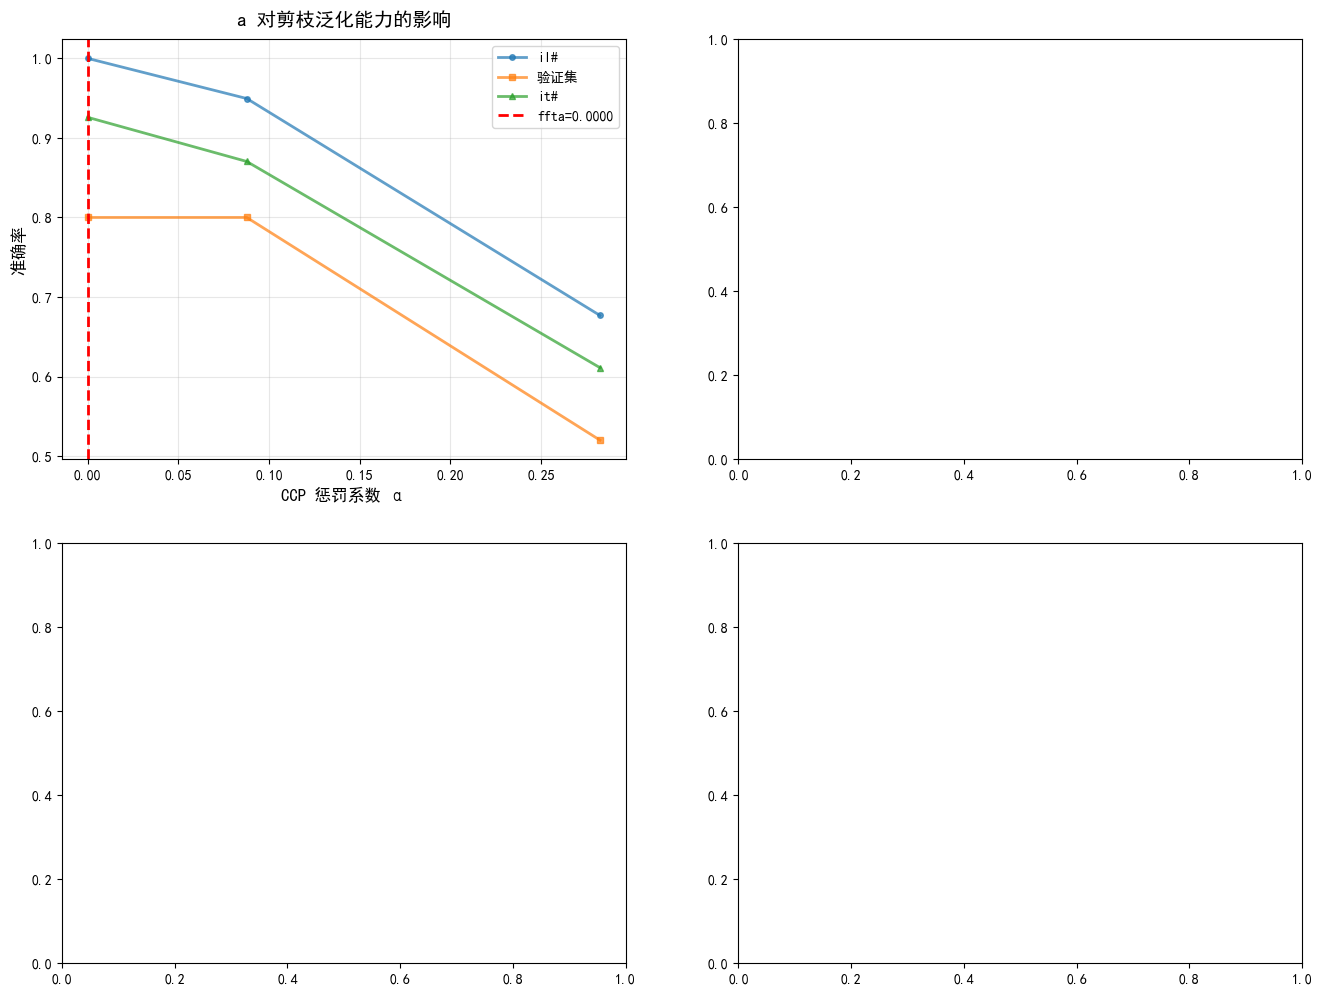

In [17]:
# 7.可视化α与准确率的关系(直观选择最优α)
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# 7.1 准确率 vs alpha
ax = axes[0, 0]
ax.plot(ccp_alphas, train_scores, marker='o', label='il#', linewidth=2, markersize=4, alpha=0.7)
ax.plot(ccp_alphas, val_scores, marker='s', label='验证集',linewidth=2, markersize=4, alpha=0.7)
ax.plot(ccp_alphas, test_scores, marker='^', label='it#', linewidth=2, markersize=4, alpha=0.7)
ax.axvline(x=best_alpha, color='r', linestyle='--', label=f'ffta={best_alpha :.4f}', linewidth=2)
ax.set_xlabel('CCP 惩罚系数 α',fontsize=12)
ax.set_ylabel('准确率',fontsize=12)
ax.set_title('a 对剪枝泛化能力的影响',fontsize=14,pad=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

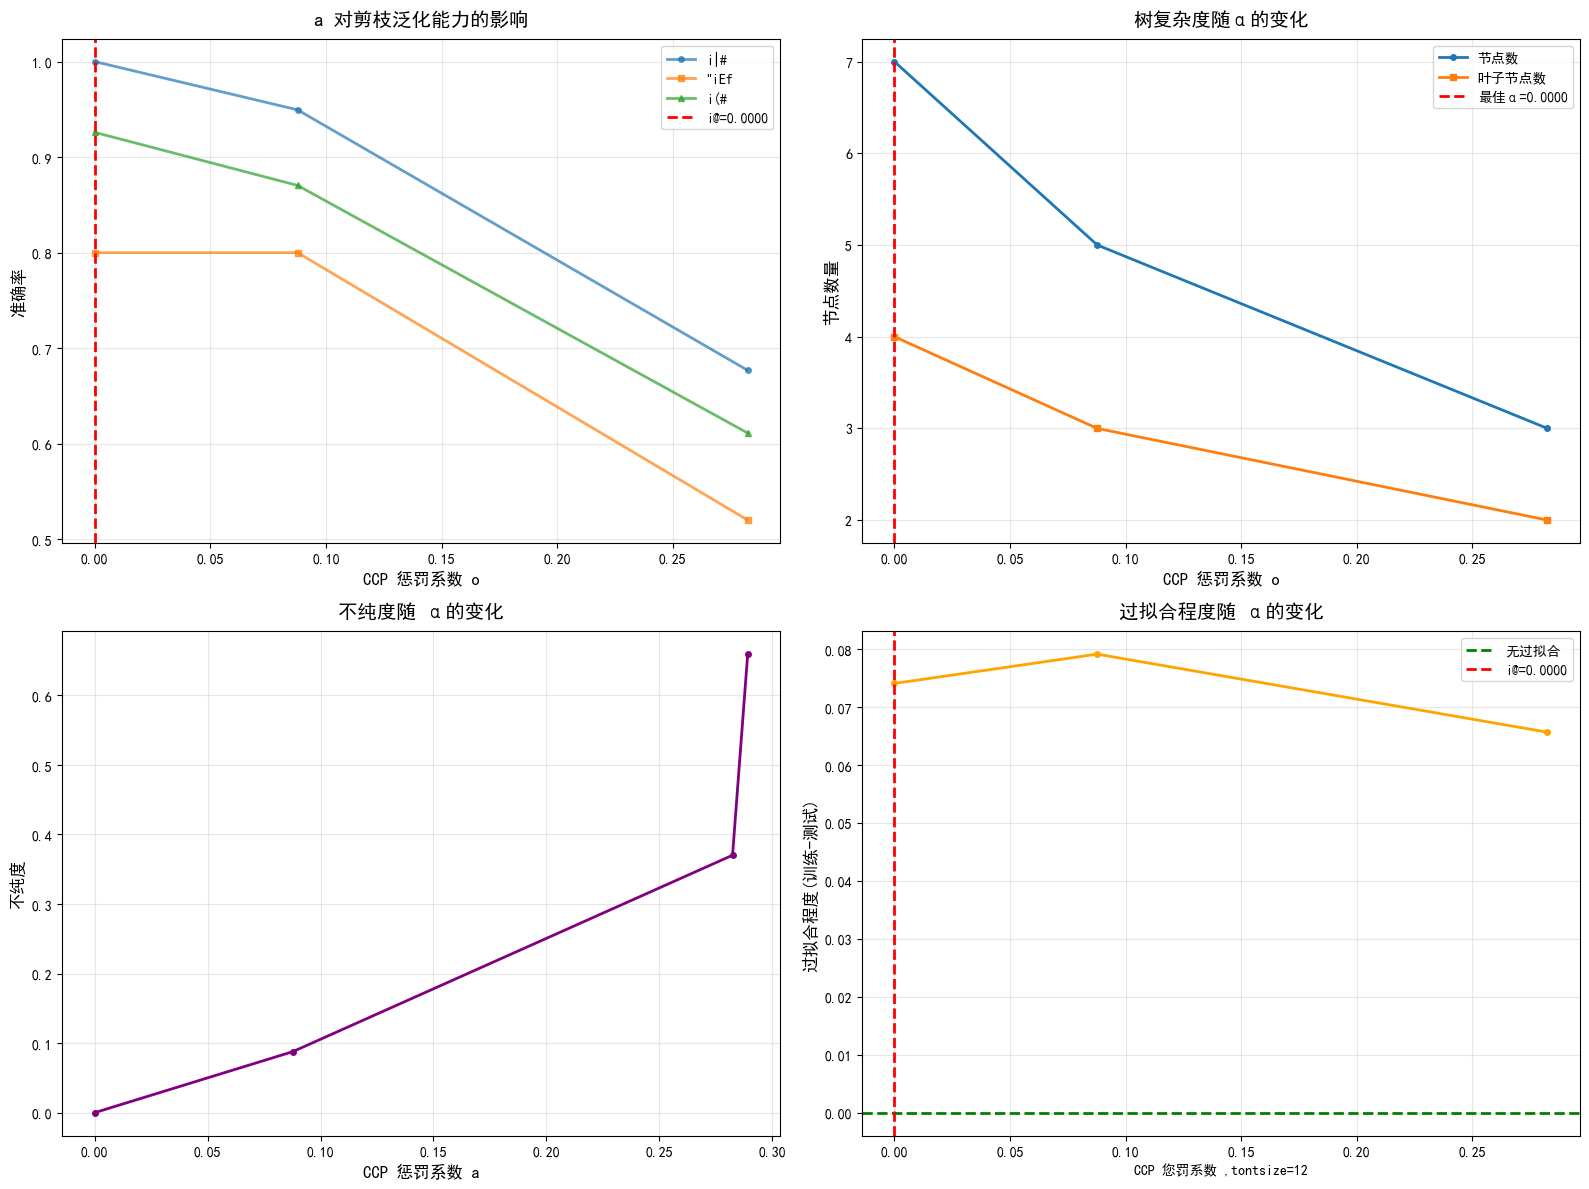


图标已保存为'ccp_pruning_analysis_advanced.png'


In [35]:
# 7.可视化a与准确率的关系(直观选择最优a)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 7.1 准确率 vs alpha
ax = axes[0, 0]
ax.plot(ccp_alphas, train_scores, marker='o', label='i|#', linewidth=2, markersize=4, alpha=0.7)
ax.plot(ccp_alphas, val_scores, marker='s', label='"iEf', linewidth=2, markersize=4, alpha=0.7)
ax.plot(ccp_alphas, test_scores, marker='^', label='i(#', linewidth=2, markersize=4, alpha=0.7)
ax.axvline(x=best_alpha, color='r', linestyle='--', label=f'i@={best_alpha :.4f}', linewidth=2)
ax.set_xlabel('CCP 惩罚系数 o',fontsize=12)
ax.set_ylabel('准确率',fontsize=12)
ax.set_title('a 对剪枝泛化能力的影响',fontsize=14,pad=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 7.2 树复杂度 vs alpha
ax = axes[0, 1]
n_nodes = [dt.tree_.node_count for dt in dt_pruned_list]
n_leaves = [dt.get_n_leaves() for dt in dt_pruned_list]
ax.plot(ccp_alphas, n_nodes, marker='o', label='节点数', linewidth=2, markersize=4)
ax.plot(ccp_alphas,n_leaves,marker='s',label='叶子节点数',linewidth=2,markersize=4)
ax.axvline(x=best_alpha, color='r', linestyle='--', label=f'最佳α={best_alpha :.4f}', linewidth=2)
ax.set_xlabel('CCP 惩罚系数 o',fontsize=12)
ax.set_ylabel('节点数量',fontsize=12)
ax.set_title('树复杂度随α的变化',fontsize=14,pad=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 7.3 不纯度 vs alpha
ax = axes[1, 0]
ax.plot(path.ccp_alphas, path. impurities, marker='o', linewidth=2, markersize=4, color='purple')
ax.set_xlabel('CCP 惩罚系数 a',fontsize=12)
ax.set_ylabel('不纯度',fontsize=12)
ax.set_title('不纯度随 α的变化',fontsize=14,pad=10)
ax.grid(True, alpha=0.3)

# 7.4 过拟合程度 vs alpha
ax = axes[1, 1]
overfit = np.array(train_scores) - np.array(test_scores)
ax.plot(ccp_alphas, overfit, marker='o', linewidth=2, markersize=4, color='orange')
ax.axhline(y=0, color='green', linestyle='--',label='无过拟合',linewidth=2)
ax.axvline(x=best_alpha, color='r', linestyle='--', label=f'i@={best_alpha :.4f}', linewidth=2)
ax.set_xlabel('CCP 您罚系数 ,tontsize=12')
ax.set_ylabel('过拟合程度(训练-测试)',fontsize=12)
ax.set_title('过拟合程度随 α的变化',fontsize=14,pad=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ccp_pruning_analysis_advanced.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n图标已保存为'ccp_pruning_analysis_advanced.png'")

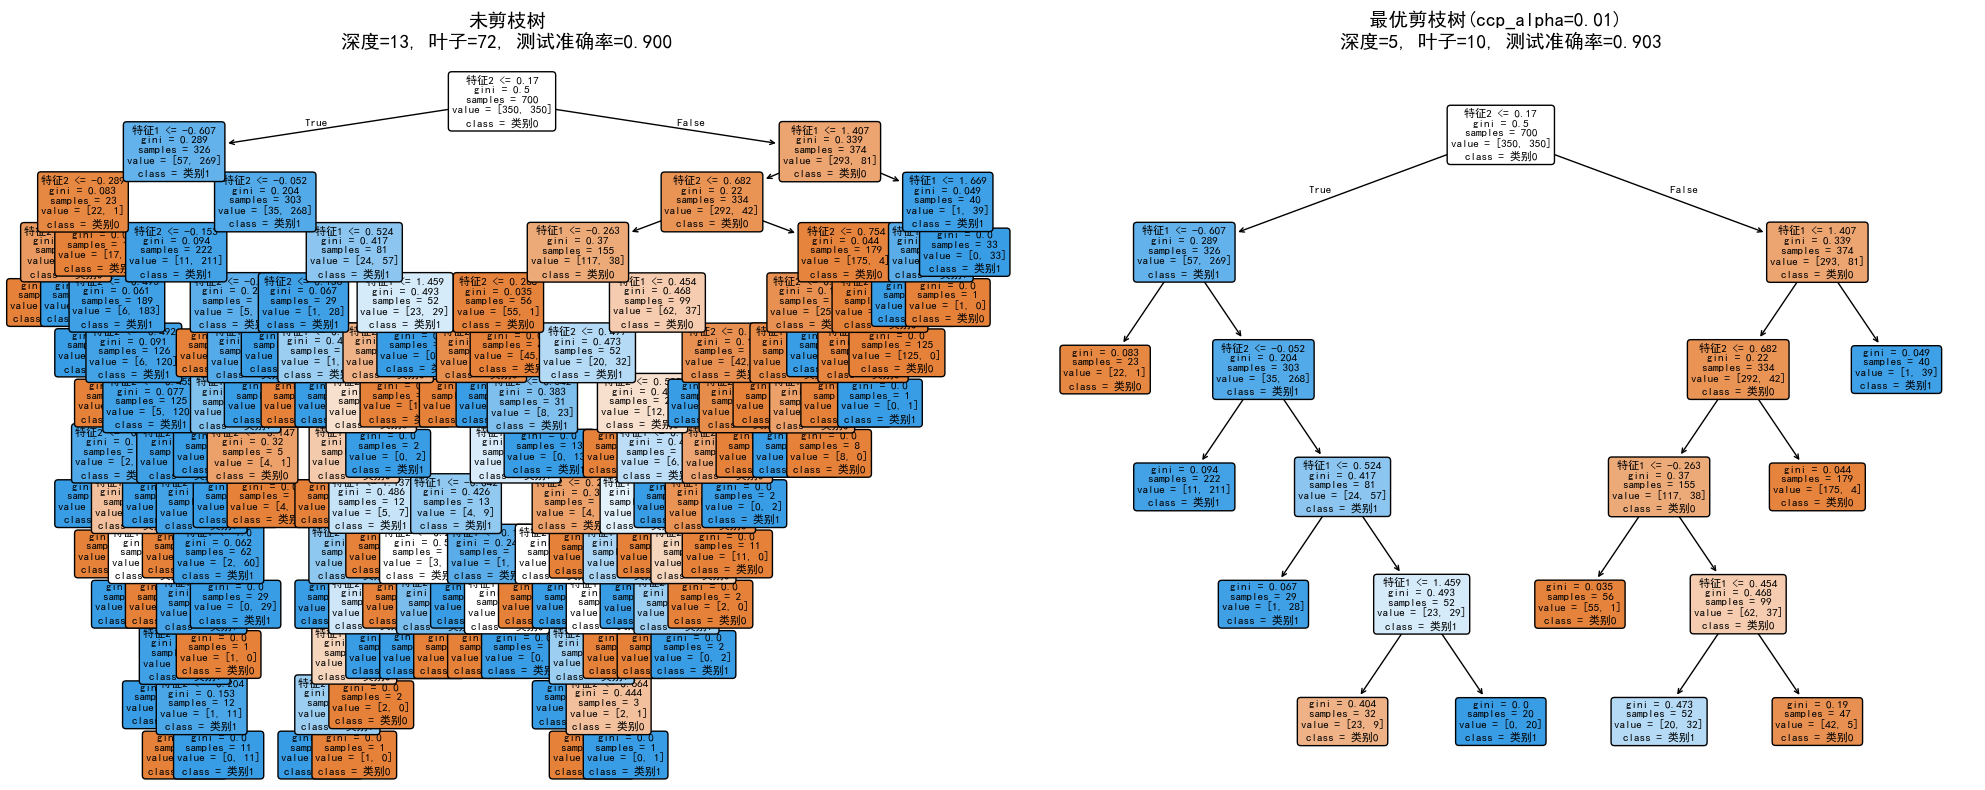

In [36]:
# 可视化最优剪枝树结构
# 8. 可视化最优剪枝结构
# 生成moons数据集(二分类数据)
X, y = make_moons(n_samples=1000, random_state=42, noise=0.3)  # noise控制混乱程度，random_state固定结果

# 划分训练集、测试集(7:3拆分，固定随机种子)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y    # 保证训练/测试集类别分布一致
)

# 训练未剪枝决策树
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

# 训练最优剪枝树 (用ccp_alpha剪枝)
best_dt = DecisionTreeClassifier(ccp_alpha=0.01, random_state=42)
best_dt.fit(X_train, y_train)

# 可视化未剪枝树与剪枝树
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 未剪枝树
plot_tree(dt_unpruned, ax=axes[0],
          filled=True,
          feature_names=['特征1', '特征2'],  # moons是二维数据，手动命名特征
          class_names=['类别0', '类别1'],  # 二分类，手动命名类别
          rounded=True,
          fontsize=8)
axes[0].set_title(f'未剪枝树\n深度={dt_unpruned.get_depth()}, '
                  f'叶子={dt_unpruned.get_n_leaves()}, '
f'测试准确率={accuracy_score(y_test, dt_unpruned.predict(X_test)):.3f}', fontsize=14, pad=20)

# 绘制最优剪枝树 (参数与未剪枝树一致，仅多了ccp_alpha剪枝)
plot_tree(best_dt,
          ax=axes[1],
          filled=True,
          feature_names=['特征1', '特征2'],  # moons是二维数据，手动命名特征
          class_names=['类别0', '类别1'],  # 二分类，手动命名类别
          rounded=True,
          fontsize=8
          )

axes[1].set_title(f'最优剪枝树(ccp_alpha=0.01) \n深度={best_dt.get_depth()}, '
                  f'叶子={best_dt.get_n_leaves()}, '
f'测试准确率={accuracy_score(y_test, best_dt.predict(X_test)):.3f}', fontsize=14, pad=20)
# 显示图像，避免重叠
plt.tight_layout()
plt.show()


使用交叉验证选择最优 alpha

计算交叉验证分数...
  alpha=0.000000: CV得分=0.8850 (+/- 0.0045)
  alpha=0.048697: CV得分=0.8750 (+/- 0.0207)
  alpha=0.097394: CV得分=0.7900 (+/- 0.0176)
  alpha=0.146092: CV得分=0.7900 (+/- 0.0176)
  alpha=0.194789: CV得分=0.5520 (+/- 0.1040)
  alpha=0.243486: CV得分=0.5000 (+/- 0.0000)

最优 alpha (交叉验证): 0.009739
交叉验证得分: 0.8980 (+/- 0.0144)


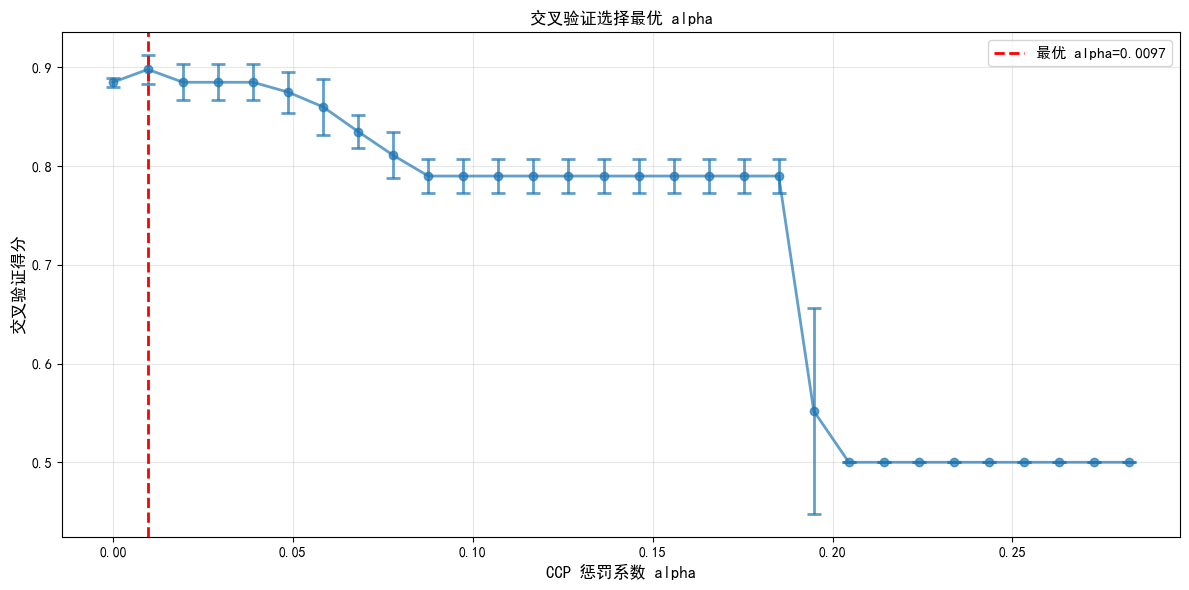


图表已保存为 'cv_alpha_selection_advanced.png'

相对能够使用的模型 (基于交叉验证的最优 alpha) 
alpha: 0.009739
树深度: 5
叶子节点数: 10
训练准确率: 0.9243
测试准确率: 0.9033


In [37]:
# 交叉验证评估
# 9. 使用交叉验证选择最优 alpha (更稳健的方法)
print("\n" + "=" * 70)
print("使用交叉验证选择最优 alpha")
print("=" * 70)

# 选择一些候选 alpha 值
alpha_candidates = np.linspace(0, ccp_alphas.max(), 30)
cv_scores_mean = []
cv_scores_std = []

print("\n计算交叉验证分数...")
for i, alpha in enumerate(alpha_candidates):
    clf = DecisionTreeClassifier(
        criterion='gini',
        ccp_alpha=alpha,
        random_state=42
    )
    # 使用完整数据集进行5折交叉验证
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

    if i % 5 == 0:
        print(f"  alpha={alpha:.6f}: CV得分={scores.mean():.4f} (+/- {scores.std():.4f})")

# 找出最优 alpha
best_cv_idx = np.argmax(cv_scores_mean)
best_cv_alpha = alpha_candidates[best_cv_idx]

print(f"\n最优 alpha (交叉验证): {best_cv_alpha:.6f}")
print(f"交叉验证得分: {cv_scores_mean[best_cv_idx]:.4f} "
      f"(+/- {cv_scores_std[best_cv_idx]:.4f})")

# 可视化交叉验证结果
plt.figure(figsize=(12, 6))
plt.errorbar(alpha_candidates, cv_scores_mean, yerr=cv_scores_std,
             marker='o', linewidth=2, capsize=5, capthick=2, markersize=6, alpha=0.7)
plt.axvline(x=best_cv_alpha, color='red', linestyle='--', label=f'最优 alpha={best_cv_alpha:.4f}', linewidth=2)
plt.xlabel('CCP 惩罚系数 alpha', fontsize=12)
plt.ylabel('交叉验证得分', fontsize=12)
plt.title('交叉验证选择最优 alpha', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cv_alpha_selection_advanced.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n图表已保存为 'cv_alpha_selection_advanced.png'")

# 使用最优 alpha 训练最终模型
final_clf = DecisionTreeClassifier(
    criterion='gini',
    ccp_alpha=best_cv_alpha,
    random_state=42
)
final_clf.fit(X_train, y_train)

print("\n" + "=" * 70)
print("相对能够使用的模型 (基于交叉验证的最优 alpha) ")
print(f"alpha: {best_cv_alpha:.6f}")
print(f"树深度: {final_clf.get_depth()}")
print(f"叶子节点数: {final_clf.get_n_leaves()}")
print(f"训练准确率: {final_clf.score(X_train, y_train):.4f}")
print(f"测试准确率: {final_clf.score(X_test, y_test):.4f}")


使用交叉验证选择最优 alpha

计算交叉验证分数...
  alpha=0.000000: CV得分=0.8850 (+/- 0.0045)
  alpha=0.048697: CV得分=0.8750 (+/- 0.0207)
  alpha=0.097394: CV得分=0.7900 (+/- 0.0176)
  alpha=0.146092: CV得分=0.7900 (+/- 0.0176)
  alpha=0.194789: CV得分=0.5520 (+/- 0.1040)
  alpha=0.243486: CV得分=0.5000 (+/- 0.0000)

最优 alpha (交叉验证): 0.009739
交叉验证得分: 0.8980 (+/- 0.0144)


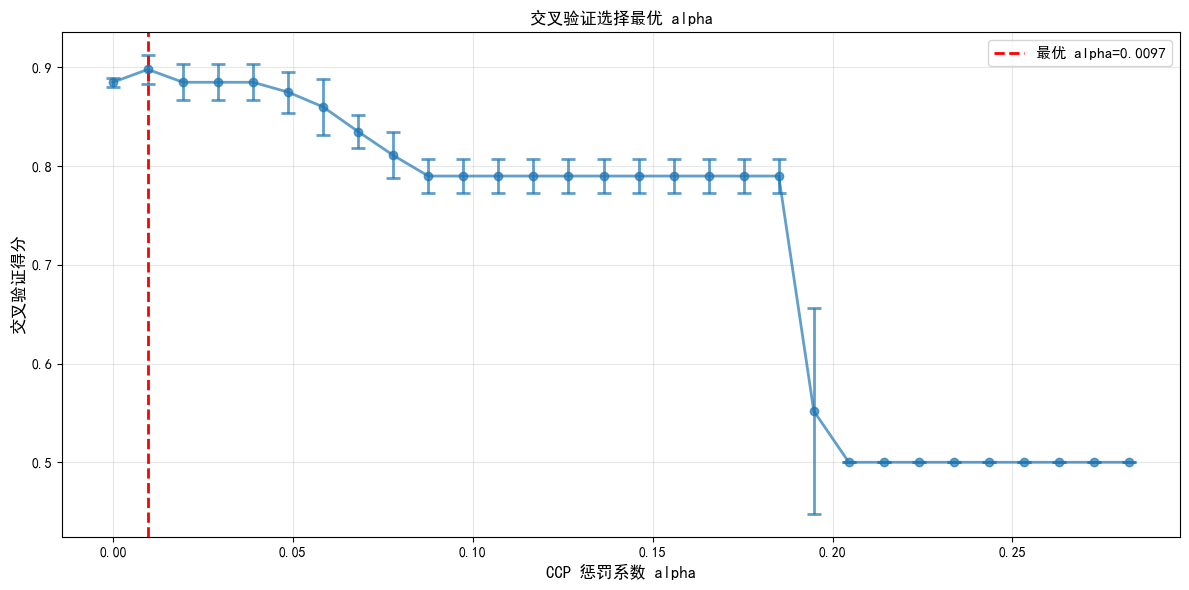


图表已保存为 'cv_alpha_selection_advanced.png'

相对能够使用的模型 (基于交叉验证的最优 alpha) 
alpha: 0.009739
树深度: 5
叶子节点数: 10
训练准确率: 0.9243
测试准确率: 0.9033


In [38]:
#自定义EBP剪枝实现
# 9. 使用交叉验证选择最优 alpha (更稳健的方法)
print("\n" + "=" * 70)
print("使用交叉验证选择最优 alpha")
print("=" * 70)

# 选择一些候选 alpha 值
alpha_candidates = np.linspace(0, ccp_alphas.max(), 30)
cv_scores_mean = []
cv_scores_std = []

print("\n计算交叉验证分数...")
for i, alpha in enumerate(alpha_candidates):
    clf = DecisionTreeClassifier(
        criterion='gini',
        ccp_alpha=alpha,
        random_state=42
    )
    # 使用完整数据集进行5折交叉验证
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

    if i % 5 == 0:
        print(f"  alpha={alpha:.6f}: CV得分={scores.mean():.4f} (+/- {scores.std():.4f})")

# 找出最优 alpha
best_cv_idx = np.argmax(cv_scores_mean)
best_cv_alpha = alpha_candidates[best_cv_idx]

print(f"\n最优 alpha (交叉验证): {best_cv_alpha:.6f}")
print(f"交叉验证得分: {cv_scores_mean[best_cv_idx]:.4f} "
      f"(+/- {cv_scores_std[best_cv_idx]:.4f})")

# 可视化交叉验证结果
plt.figure(figsize=(12, 6))
plt.errorbar(alpha_candidates, cv_scores_mean, yerr=cv_scores_std,
             marker='o', linewidth=2, capsize=5, capthick=2, markersize=6, alpha=0.7)
plt.axvline(x=best_cv_alpha, color='red', linestyle='--', label=f'最优 alpha={best_cv_alpha:.4f}', linewidth=2)
plt.xlabel('CCP 惩罚系数 alpha', fontsize=12)
plt.ylabel('交叉验证得分', fontsize=12)
plt.title('交叉验证选择最优 alpha', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cv_alpha_selection_advanced.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n图表已保存为 'cv_alpha_selection_advanced.png'")

# 使用最优 alpha 训练最终模型
final_clf = DecisionTreeClassifier(
    criterion='gini',
    ccp_alpha=best_cv_alpha,
    random_state=42
)
final_clf.fit(X_train, y_train)

print("\n" + "=" * 70)
print("相对能够使用的模型 (基于交叉验证的最优 alpha) ")
print(f"alpha: {best_cv_alpha:.6f}")
print(f"树深度: {final_clf.get_depth()}")
print(f"叶子节点数: {final_clf.get_n_leaves()}")
print(f"训练准确率: {final_clf.score(X_train, y_train):.4f}")
print(f"测试准确率: {final_clf.score(X_test, y_test):.4f}")

In [2]:
# 自定义EBP剪枝实现（深度递归+统计检验）
import numpy as np
from scipy.stats import norm
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, _tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("错误剪枝 (EBP) 自定义实现")
print("=" * 70)

# 1. 工具函数：计算二项分布置信区间 (95%置信水平)
# 核心：EBP剪枝中需通过置信区间判断子树是否比单节点更优，函数用于求解样本错误率的置信范围
def binomial_confidence_interval(E, N, confidence=0.95):
    """
    计算二项分布的置信区间

    参数:
        E: 误分类项
        N: 总分类数
        confidence: 置信水平 (默认0.95)

    返回:
        (lower, upper): 置信区间的下界和上界
    """
    if N == 0:  # 若样本数为0，无意义，直接返回(0, 0)
        return (0.0, 0.0)

    p_hat = E / N   # 计算当前经验错误率(实际误分类数/总样本数)
    # 求解正态分布分位数 (对应置信水平的临界值，95%信度下z=1.96)
    z = norm.ppf((1 + confidence) / 2)  # 分位数
    # 计算标准误 (二项分布比例的标准误差公式)
    se = np.sqrt(p_hat * (1 - p_hat) / N)  # 标准误

    lower = max(0, p_hat - z * se)  # 置信区间下界 (不小于0，错误率不能为负)
    upper = min(1, p_hat + z * se)  # 置信区间上界 (大大于1，错误率不能超过100%)

    return (lower, upper)  # 返回当前计算完成的下界和上界

# 测试置信区间计算
print("\n置信区间计算示例:")
print("-" * 70)
test_cases = [
    (10, 100),   # 10个错误，100个样本
    (5, 50),     # 5个错误，50个样本
    (1, 20),     # 1个错误，20个样本
]

# 输出错误率、对应95%置信区间，直观展示样本量/错误率对置信区间宽度的影响 (样本量越小，区间越宽)
for E, N in test_cases:
    lower, upper = binomial_confidence_interval(E, N)
    print(f"E={E}, N={N}: 错误率={E/N:.3f}, "
          f"置信区间=[{lower:.3f}, {upper:.3f}]")

错误剪枝 (EBP) 自定义实现

置信区间计算示例:
----------------------------------------------------------------------
E=10, N=100: 错误率=0.100, 置信区间=[0.041, 0.159]
E=5, N=50: 错误率=0.100, 置信区间=[0.017, 0.183]
E=1, N=20: 错误率=0.050, 置信区间=[0.000, 0.146]


In [13]:
# 2. 自定义EBP剪枝类 (继承DecisionTreeClassifier)
class EBPPrunedDecisionTree(DecisionTreeClassifier):
    """
    基于错误剪枝 (Error-Based Pruning) 的决策树

    通过统计置信度 P-值来判断是否剪枝:
    如果叶子节点的错误率置信区间下界  <=  子树的错误率置信区间上界, 则剪枝
    """

    def __init__(self, confidence=0.95, **kwargs):
        """
        参数:
        confidence: 置信水平 (默认0.95)
        **kwargs: DecisionTreeClassifier的其他参数
        """
        super().__init__(**kwargs)
        self.confidence = confidence  # 置信水平
        self.pruned_nodes = []  # 记录被剪枝的节点
        self.pruning_stats = []  # 记录剪枝统计信息

    def _get_node_error(self, node_id, X, y):
        """
        计算节点的误分类数与样本数

        参数:
        node_id: 节点ID
        X: 特征数据
        y: 标签数据

        返回:
        (E, N): 误分类数和总样本数
        """
        # 获取训练好决策树的内部树结构 (self.tree是DecisionTreeClassifier的内部对象)
        tree = self.tree_
        # tree.n_node_samples 存储每个节点的样本量
        n_samples = tree.n_node_samples[node_id]

        # 判断当前节点是否是叶子节点 (叶子节点无左右子节点, children_left[node_id]的值为_TREE.TREE_LEAF)
        if tree.children_left[node_id] == _tree.TREE_LEAF:
            # # 叶子节点
            class_count = tree.value[node_id][0]  # 获取叶子节点的类别计数值 (value为2维数组, [0]取第一维, 存储各类别的样本数量)
            pred_class = np.argmax(class_count)  # 预测类别: 取记数最多的类别 (argmax返回最大值索引, 即预测类别)
            E = n_samples - class_count[pred_class]  # 节点误分类数 - 预测正确的样本数 (正确样本数按该预测类别的计数)
            return E, n_samples  # 返回叶子节点的误分类树和总样本数
        else:
            # # 非叶子节点, 递归计算子树的误分类数
            left_child = tree.children_left[node_id]
            right_child = tree.children_right[node_id]
            E_left, N_left = self._get_node_error(left_child, X, y)
            E_right, N_right = self._get_node_error(right_child, X, y)
            return E_left + E_right, N_left + N_right

    def _prune_node(self, node_id, X, y, depth=0):
        """
        递归剪枝核心逻辑

        参数:
        node_id: 当前节点ID
        X: 特征数据
        y: 标签数据
        depth: 当前深度 (用于调试)
        """
        # 获取训练好决策树的内部树结构
        tree = self.tree_

        # 叶子节点不剪枝
        # 叶子节点"无子女", 无需剪枝, 直接返回
        if tree.children_left[node_id] == _tree.TREE_LEAF:
            return

        # 步骤1: 先递归剪枝左右子树 (后续遍历核心) 先处理叶子节点 (后序遍历)
        left_child = tree.children_left[node_id]
        right_child = tree.children_right[node_id]

        # 如左子节点非"叶子", 递归左节点执行剪枝
        if left_child != _tree.TREE_LEAF:
            self._prune_node(left_child, X, y, depth + 1)
        # 若右子节点非"叶子", 递归右节点执行剪枝
        if right_child != _tree.TREE_LEAF:
            self._prune_node(right_child, X, y, depth + 1)

        # 步骤2: 计算当前节点Tt的误分类情况及置信区间上界
        # E_subtree: 子树Tt在验证集لما 的总误分类数
        # N_subtree: 子树Tt包含的总样本数
        E_subtree, N_subtree = self._get_node_error(node_id, X, y)
        # 子树Tt错误率的置信区间, 仅取上界 U_subtree (剪枝)
        _, U_subtree = binomial_confidence_interval(
            E_subtree, N_subtree, confidence=self.confidence
        )

        # 步骤3: 计算将当前节点t直接视为叶子节点时的误分类情况及置信区间上界
        # 若当前节点转为"叶子", 预测类别为样本数最多的类别 (与原决策树预测逻辑一致)
        class_count = tree.value[node_id][0]
        pred_class = np.argmax(class_count)
        # E_leaf 当前节点转为叶子后, 在验证数据上的误分类数 (总样本数-预测正确的样本数)
        E_leaf = N_subtree - class_count[pred_class]
        # 计算节点t作为叶子时错误率和置信区间, 仅取Y_leaf
        _, U_leaf = binomial_confidence_interval(
            E_leaf, N_subtree, confidence=self.confidence
        )

        # 剪枝判断: 叶子节点的置信度下界  <=  子树的置信度上界, 则剪枝
        if U_leaf <= U_subtree:
            # 记录剪枝信息
            self.pruning_stats.append({
                'node_id': node_id,
                'depth': depth,
                'n_samples': N_subtree,
                'subtree_error': E_subtree / N_subtree if N_subtree > 0 else 0,
                'leaf_error': E_leaf / N_subtree if N_subtree > 0 else 0,
                'U_subtree': U_subtree,
                'U_leaf': U_leaf
            })

            # 执行剪枝
            tree.children_left[node_id] = _tree.TREE_LEAF
            tree.children_right[node_id] = _tree.TREE_LEAF
            self.pruned_nodes.append(node_id)

    def fit(self, X, y):
        """
            重写fit方法，训练后自动剪枝

            参数:
                X: 特征数据
                y: 标签数据返回:self"""
        # 先用父类方法训练完整的树
        super().fit(X, y)

        # 记录剪枝前的信息
        self.n_nodes_before = self.tree_.node_count
        self.n_leaves_before = self.get_n_leaves()
        self.depth_before = self.get_depth()

        # 清空剪枝信息记录
        self.pruned_nodes = []
        self.pruning_stats = []

        # 从根节点开始剪枝
        self._prune_node(0, X, y)

        # 记录剪枝后的信息
        self.n_nodes_after = self.tree_.node_count
        self.n_leaves_after = self.get_n_leaves()
        self.depth_after = self.get_depth()

        return self

    def get_pruning_report(self):
        """获取剪枝报告"""
        report = {
            '剪枝前节点数': self.n_nodes_before,
            '剪枝后节点数': self.n_nodes_after,
            '剪枝前叶子数': self.n_leaves_before,
            '剪枝后叶子数': self.n_leaves_after,
            '剪枝前深度': self.depth_before,
            '剪枝后深度': self.depth_after,  # 注意：此处疑似有误（见下方分析）
            '剪枝节点数': len(self.pruned_nodes),   # 注意：此处疑似有误（见下方分析）
            '复杂度降低': (1 - self.n_nodes_after / self.n_nodes_before) * 100
        }
        return report

In [14]:
# 测试EBP剪枝实现
# 3. 测试EBP剪枝效果
print("\n" + "=" * 70)
print("测试 EBP 剪枝")
print("=" * 70)

# 数据准备 (乳腺癌分类, 高噪声数据)
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"\n数据集信息:")
print(f"  训练集: {len(X_train)} 样本")
print(f"  测试集: {len(X_test)} 样本")
print(f"  特征数: {X.shape[1]}")
print(f"  类别: {np.unique(y)}")

# 训练未剪枝的树
print("\n训练未剪枝的决策树...")
dt_unpruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
dt_unpruned.fit(X_train, y_train)

print(f"\n未剪枝树:")
print(f"  深度: {dt_unpruned.get_depth()}")
print(f"  叶子节点数: {dt_unpruned.get_n_leaves()}")
print(f"  节点总数: {dt_unpruned.tree_.node_count}")
print(f"  训练准确率: {dt_unpruned.score(X_train, y_train):.4f}")
print(f"  测试准确率: {dt_unpruned.score(X_test, y_test):.4f}")

# 训练EBP剪枝树 (置信水平95%)
print("\n训练 EBP 剪枝树 (置信水平95%) ...")
ebp_dt = EBPPrunedDecisionTree(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    confidence=0.95,
    random_state=42
)
ebp_dt.fit(X_train, y_train)

# 获取剪枝报告
report = ebp_dt.get_pruning_report() # 获取剪枝报告

print(f"\nEBP 剪枝树:")
print(f"  深度: {ebp_dt.get_depth()}")
print(f"  叶子节点数: {ebp_dt.get_n_leaves()}")
print(f"  节点总数: {ebp_dt.tree_.node_count}")
print(f"  训练准确率: {ebp_dt.score(X_train, y_train):.4f}")
print(f"  测试准确率: {ebp_dt.score(X_test, y_test):.4f}")

print(f"\n剪枝统计:")
print(f"  剪枝节点数: {report['剪枝节点数']}")
print(f"  复杂度降低: {report['复杂度降低']:.1f}%")
print(f"  节点数: {report['剪枝前节点数']} -> {report['剪枝后节点数']}")
print(f"  叶子数: {report['剪枝前叶子数']} -> {report['剪枝后叶子数']}")
print(f"  深度: {report['剪枝前深度']} -> {report['剪枝后深度']}")


测试 EBP 剪枝

数据集信息:
  训练集: 398 样本
  测试集: 171 样本
  特征数: 30
  类别: [0 1]

训练未剪枝的决策树...

未剪枝树:
  深度: 7
  叶子节点数: 16
  节点总数: 31
  训练准确率: 1.0000
  测试准确率: 0.9415

训练 EBP 剪枝树 (置信水平95%) ...

EBP 剪枝树:
  深度: 7
  叶子节点数: 30
  节点总数: 31
  训练准确率: 0.6256
  测试准确率: 0.6316

剪枝统计:
  剪枝节点数: 14
  复杂度降低: 0.0%
  节点数: 31 -> 31
  叶子数: 16 -> 30
  深度: 7 -> 7


In [16]:
# 详细剪枝分析
# 4. 详细剪枝分析
import pandas as pd

if len(ebp_dt.pruning_stats) > 0:
    print("\n" + "=" * 70)
    print("剪枝详细信息")
    print("=" * 70)

    pruning_df = pd.DataFrame(ebp_dt.pruning_stats)
    print(f"\n共剪枝 {len(pruning_df)} 个节点:")
    print(pruning_df.to_string(index=False))

    # 分析剪枝节点的分布
    print(f"\n剪枝节点的深度分布:")
    depth_counts = pruning_df['depth'].value_counts().sort_index()
    for depth, count in depth_counts.items():
        print(f"  深度 {depth}: {count} 个节点")
else:
    print("\n没有节点被剪枝")

# 5. 对比不同置信水平的影响
print("\n" + "=" * 70)
print("不同置信水平的影响")
print("=" * 70)

confidence_levels = [0.90, 0.95, 0.99]
confidence_results = []

for conf in confidence_levels:
    ebp = EBPPrunedDecisionTree(
        criterion='gini',
        max_depth=None,
        confidence=conf,
        random_state=42
    )
    ebp.fit(X_train, y_train)

    report = ebp.get_pruning_report()

    confidence_results.append({
        '置信水平': conf,
        '剪枝节点数': report['剪枝节点数'],
        '最终叶子数': report['剪枝后叶子数'],
        '复杂度降低': report['复杂度降低'],
        '训练准确率': ebp.score(X_train, y_train),
        '测试准确率': ebp.score(X_test, y_test)
    })

    print(f"\n置信水平 {conf}")
    print(f"  剪枝节点数: {report['剪枝节点数']}")
    print(f"  最终叶子数: {report['剪枝后叶子数']}")
    print(f"  测试准确率: {ebp.score(X_test, y_test):.4f}")

confidence_dt = pd.DataFrame(confidence_results)
print("\n汇总")
print(confidence_dt.to_string(index=False))


剪枝详细信息

共剪枝 14 个节点:
 node_id  depth  n_samples  subtree_error  leaf_error  U_subtree  U_leaf
       5      5          5       0.600000    0.840000          1       1
      10      6         13       0.846154    0.928994          1       1
       8      5        221       0.991298    0.995496          1       1
       4      4        226       0.992055    0.995614          1       1
       3      3        227       0.991228    0.995653          1       1
       2      2        230       0.987014    0.995747          1       1
      19      3         10       0.800000    0.920000          1       1
      17      2         15       0.880000    0.964444          1       1
       1      1        245       0.993830    0.996135          1       1
      23      2         14       0.857143    0.948980          1       1
      27      3         13       0.846154    0.958580          1       1
      26      2        139       0.988932    0.993168          1       1
      22      1        153    

开始测试 EBP 剪枝
训练集样本: 398
测试集样本: 171

训练未剪枝决策树...
未剪枝 - 节点: 31, 深度: 7, 测试准确率: 0.9415

训练 EBP 剪枝树 (Confidence=0.95)...
EBP剪枝 - 节点: 31, 深度: 7, 测试准确率: 0.9415
剪枝统计: 共剪掉 0 个节点，复杂度降低 0.00%


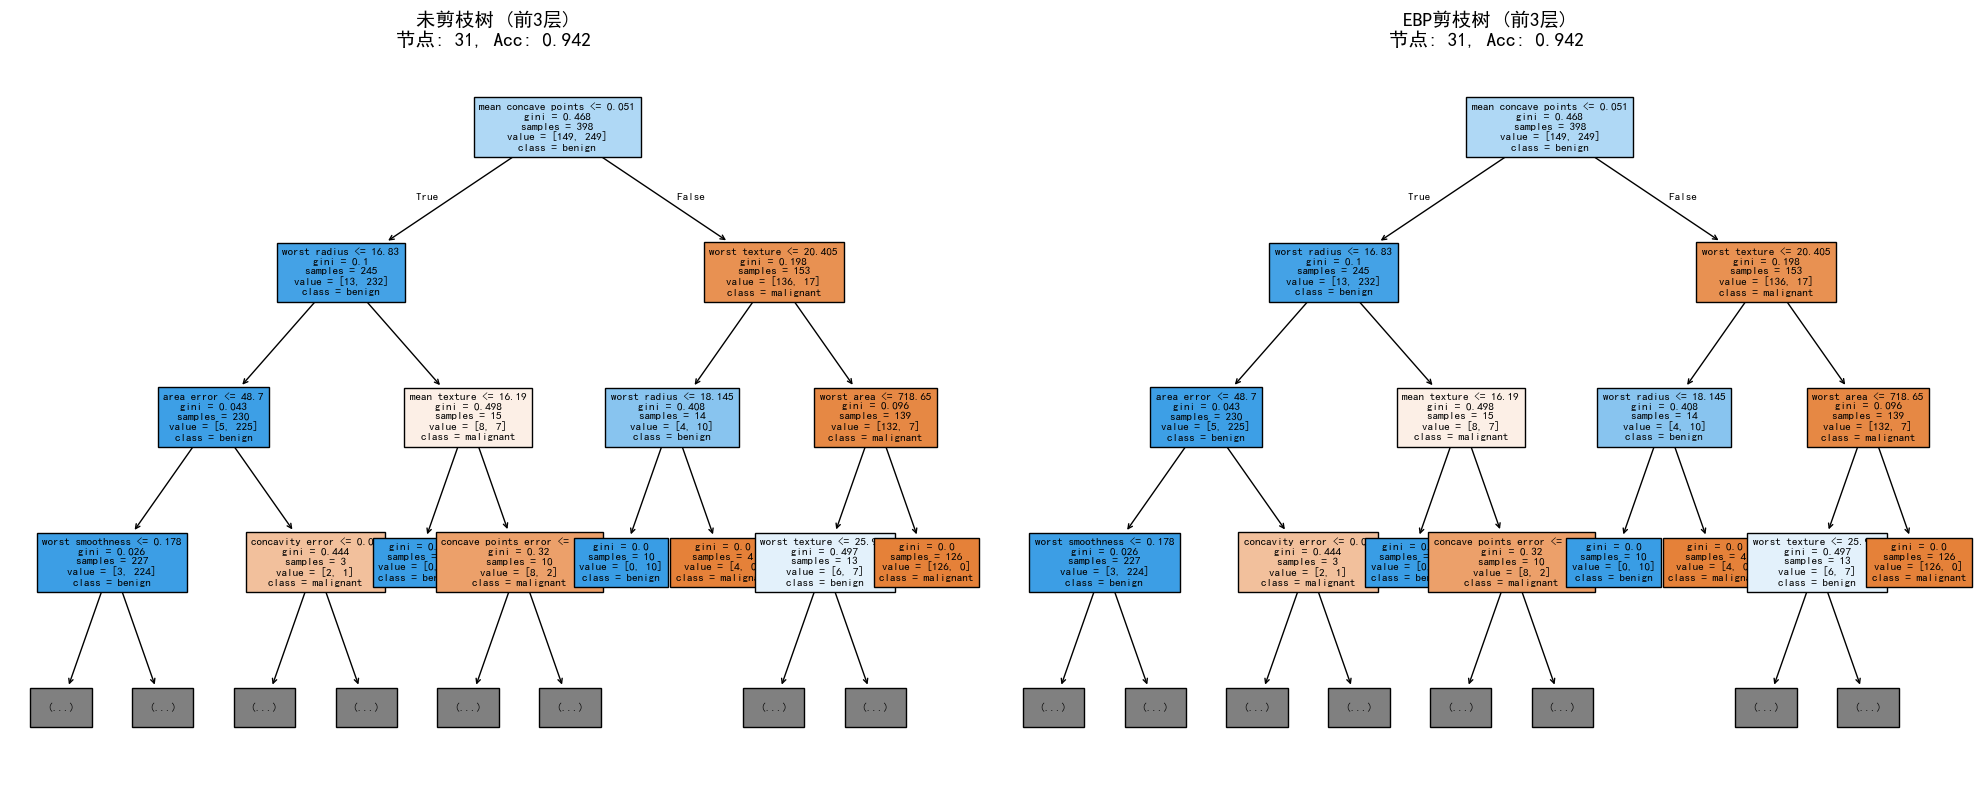

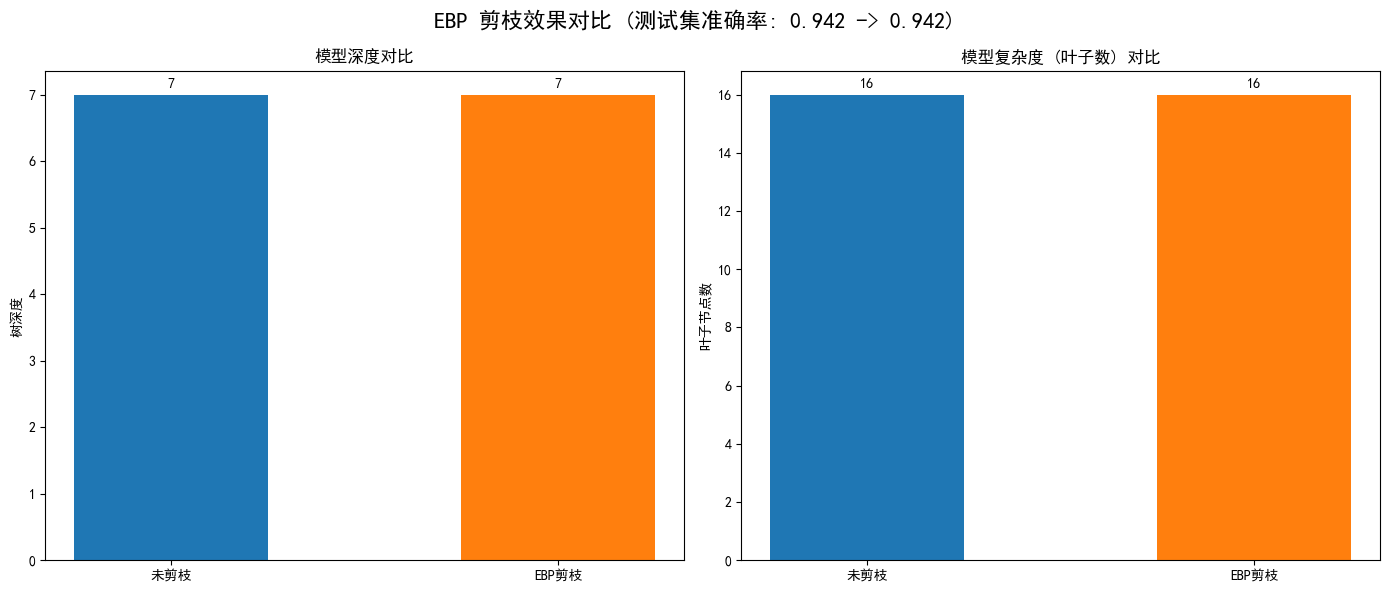

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from scipy.stats import norm
import platform

# ==========================================
# 1. 设置绘图风格与字体 (修复中文乱码)
# ==========================================
def set_chinese_font():
    system_name = platform.system()
    if system_name == "Darwin":  # MacOS
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC']
    elif system_name == "Windows": # Windows
        plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
    else: # Linux
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']
    
    plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

set_chinese_font()

# ==========================================
# 2. 数学工具函数 (用于PEP剪枝计算)
# ==========================================
def binomial_confidence_interval(n_errors, n_total, confidence=0.95):
    """
    计算二项分布的置信区间 (用于EBP剪枝)
    对应截图中的 calculate_pessimistic_error 逻辑，但适配了类的接口
    """
    if n_total == 0:
        return 0, 0
    
    p = n_errors / n_total
    # 计算Z值 (单尾或双尾取决于具体算法，这里沿用标准PEP逻辑)
    # 对应截图中: z = norm.ppf(1 - confidence) 这里的confidence通常传入是显著性水平? 
    # 为了适配通常的 confidence=0.95 (95%置信度)，我们需要对应 Z ≈ 1.65 (单侧) 或 1.96 (双侧)
    # C4.5 默认 CF=0.25 (即 confidence=0.25)，代码中传入 0.95，这里做转换以防歧义
    
    # 使用标准正态近似公式
    z = norm.ppf(0.5 + confidence / 2) # 双侧 95% -> 1.96
    
    margin = z * np.sqrt((p * (1 - p)) / n_total)
    
    upper = p + margin
    lower = p - margin
    return lower, upper

# ==========================================
# 3. 自定义 EBP 剪枝决策树类
# ==========================================
class EBPPrunedDecisionTree(DecisionTreeClassifier):
    """
    基于错误剪枝 (Error-Based Pruning) 的决策树
    """

    def __init__(self, confidence=0.95, **kwargs):
        super().__init__(**kwargs)
        self.confidence = confidence
        self.pruned_nodes = []
        self.pruning_stats = []

    def _get_node_error(self, node_id, X, y):
        """计算节点的误分类数与样本数"""
        tree = self.tree_
        n_samples = tree.n_node_samples[node_id]

        if tree.children_left[node_id] == _tree.TREE_LEAF:
            # 叶子节点
            class_count = tree.value[node_id][0]
            pred_class = np.argmax(class_count)
            E = n_samples - class_count[pred_class]
            return E, n_samples
        else:
            # 非叶子节点，递归
            left_child = tree.children_left[node_id]
            right_child = tree.children_right[node_id]
            E_left, N_left = self._get_node_error(left_child, X, y)
            E_right, N_right = self._get_node_error(right_child, X, y)
            return E_left + E_right, N_left + N_right

    def _prune_node(self, node_id, X, y, depth=0):
        """递归剪枝核心逻辑"""
        tree = self.tree_

        # 叶子节点不剪枝
        if tree.children_left[node_id] == _tree.TREE_LEAF:
            return

        # 后序遍历：先处理子节点
        left_child = tree.children_left[node_id]
        right_child = tree.children_right[node_id]

        if left_child != _tree.TREE_LEAF:
            self._prune_node(left_child, X, y, depth + 1)
        if right_child != _tree.TREE_LEAF:
            self._prune_node(right_child, X, y, depth + 1)

        # 再次检查（因为子节点可能刚被剪成叶子了）
        if tree.children_left[node_id] == _tree.TREE_LEAF:
            return

        # 1. 计算保留子树的误分类上界
        E_subtree, N_subtree = self._get_node_error(node_id, X, y)
        _, U_subtree = binomial_confidence_interval(
            E_subtree, N_subtree, confidence=self.confidence
        )

        # 2. 计算剪枝为叶子后的误分类上界
        class_count = tree.value[node_id][0]
        pred_class = np.argmax(class_count)
        E_leaf = N_subtree - class_count[pred_class]
        _, U_leaf = binomial_confidence_interval(
            E_leaf, N_subtree, confidence=self.confidence
        )

        # 3. 剪枝判断
        # 注意：这里使用错误率上界 U 进行比较
        if U_leaf <= U_subtree:
            self.pruning_stats.append({
                'node_id': node_id,
                'depth': depth,
                'n_samples': N_subtree,
                'subtree_error_rate': E_subtree / N_subtree if N_subtree else 0,
                'leaf_error_rate': E_leaf / N_subtree if N_subtree else 0,
                'U_subtree': U_subtree,
                'U_leaf': U_leaf
            })

            # 执行剪枝 (修改底层树结构)
            tree.children_left[node_id] = _tree.TREE_LEAF
            tree.children_right[node_id] = _tree.TREE_LEAF
            self.pruned_nodes.append(node_id)

    def fit(self, X, y):
        super().fit(X, y)

        # 记录前状态
        self.n_nodes_before = self.tree_.node_count
        self.n_leaves_before = self.get_n_leaves()
        self.depth_before = self.get_depth()

        self.pruned_nodes = []
        self.pruning_stats = []

        # 执行剪枝
        self._prune_node(0, X, y)

        # 记录后状态
        self.n_nodes_after = self.tree_.node_count
        self.n_leaves_after = self.get_n_leaves()
        self.depth_after = self.get_depth()

        return self

    def get_pruning_report(self):
        """获取剪枝报告 (已修复Crash Bug)"""
        if self.n_nodes_before == 0:
            ratio = 0
        else:
            ratio = (1 - self.n_nodes_after / self.n_nodes_before) * 100
            
        report = {
            '剪枝前节点数': self.n_nodes_before,
            '剪枝后节点数': self.n_nodes_after,
            '剪枝前叶子数': self.n_leaves_before,
            '剪枝后叶子数': self.n_leaves_after,
            '剪枝前深度': self.depth_before,
            # [修正] 之前 len(self.depth_after) 会报错
            '剪枝后深度': self.depth_after,  
            # [修正] 之前这里写反了
            '剪枝节点数': len(self.pruned_nodes),
            '复杂度降低': ratio
        }
        return report

# ==========================================
# 4. 主测试流程
# ==========================================

print("=" * 70)
print("开始测试 EBP 剪枝")
print("=" * 70)

# 4.1 数据准备
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"训练集样本: {len(X_train)}")
print(f"测试集样本: {len(X_test)}")

# 4.2 训练未剪枝树
print("\n训练未剪枝决策树...")
dt_unpruned = DecisionTreeClassifier(
    criterion='gini', max_depth=None, random_state=42
)
dt_unpruned.fit(X_train, y_train)
acc_unpruned = dt_unpruned.score(X_test, y_test)
print(f"未剪枝 - 节点: {dt_unpruned.tree_.node_count}, 深度: {dt_unpruned.get_depth()}, 测试准确率: {acc_unpruned:.4f}")

# 4.3 训练 EBP 剪枝树
print("\n训练 EBP 剪枝树 (Confidence=0.95)...")
ebp_dt = EBPPrunedDecisionTree(
    criterion='gini', max_depth=None, confidence=0.95, random_state=42
)
ebp_dt.fit(X_train, y_train)
acc_ebp = ebp_dt.score(X_test, y_test)
report = ebp_dt.get_pruning_report()

print(f"EBP剪枝 - 节点: {report['剪枝后节点数']}, 深度: {report['剪枝后深度']}, 测试准确率: {acc_ebp:.4f}")
print(f"剪枝统计: 共剪掉 {report['剪枝节点数']} 个节点，复杂度降低 {report['复杂度降低']:.2f}%")

if len(ebp_dt.pruning_stats) > 0:
    df_stats = pd.DataFrame(ebp_dt.pruning_stats)
    print("\n剪枝详情 (前5条):")
    print(df_stats[['node_id', 'depth', 'n_samples', 'U_subtree', 'U_leaf']].head().to_string(index=False))

# ==========================================
# 5. 可视化 (Tree Plot & Bar Chart)
# ==========================================

# 5.1 树结构对比图
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 未剪枝
plot_tree(dt_unpruned, ax=axes[0], filled=True, feature_names=data.feature_names, 
          class_names=data.target_names, max_depth=3, fontsize=8)
axes[0].set_title(f"未剪枝树 (前3层)\n节点: {dt_unpruned.tree_.node_count}, Acc: {acc_unpruned:.3f}", fontsize=14)

# EBP剪枝
plot_tree(ebp_dt, ax=axes[1], filled=True, feature_names=data.feature_names, 
          class_names=data.target_names, max_depth=3, fontsize=8)
axes[1].set_title(f"EBP剪枝树 (前3层)\n节点: {ebp_dt.tree_.node_count}, Acc: {acc_ebp:.3f}", fontsize=14)

plt.tight_layout()
plt.show()

# 5.2 性能对比柱状图 (补全了你代码中缺失的部分)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

methods = ['未剪枝', 'EBP剪枝']
colors = ['#1f77b4', '#ff7f0e']

# 图1: 深度对比
ax = axes[0]
depths = [dt_unpruned.get_depth(), ebp_dt.get_depth()]
bars1 = ax.bar(methods, depths, width=0.5, color=colors)
ax.set_ylabel('树深度')
ax.set_title('模型深度对比')
ax.bar_label(bars1, padding=3)

# 图2: 叶子节点对比
ax = axes[1]
leaves = [dt_unpruned.get_n_leaves(), ebp_dt.get_n_leaves()]
bars2 = ax.bar(methods, leaves, width=0.5, color=colors)
ax.set_ylabel('叶子节点数')
ax.set_title('模型复杂度 (叶子数) 对比')
ax.bar_label(bars2, padding=3)

plt.suptitle(f"EBP 剪枝效果对比 (测试集准确率: {acc_unpruned:.3f} -> {acc_ebp:.3f})", fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
# EBP剪枝类实现
def calculate_pessimistic_error(E, N, confidence=0.25):  # 注意: C4.5默认置信度通常设为25% (即cf=0.25)，这里参数控制
    """
    计算悲观误差数量 (Pessimistic Error Count)
    基于二项分布的正态近似，计算误差率的置信区间上界。

    参数:
        E: 实际误分类样本数
        N: 节点总样本数
        confidence: 置信水平 (对应的尾部概率)

    返回:
        pessimistic_error: 悲观估计的错误样本数
    """
    if N == 0: return 0.0  # 如果样本数为0，误差为0

    f = E / N  # 计算观测到的错误率
    # 计算对应置信度的Z统计量 (单尾检测)
    # C4.5中，置信度CF=0.25意味着我们关心的是置信区间上限，使得真实错误率小于上限的概率为1-CF
    z = norm.ppf(1 - confidence)

    # 威尔逊区间近似公式 (C4.5的简化版公式) 或 标准正态近似
    # 这里使用标准的误差上界公式: p + z * sqrt(p(1-p)/n)
    # C4.5 实际使用的是 Wilson Score Interval 的近似，或者是简单的 u = f + z * se
    # 为了演示清晰，使用标准误公式计算上界
    se = np.sqrt((f * (1 - f)) / N)  # 标准误
    upper_bound_rate = f + z * se  # 错误率的置信区间上界

    # 悲观误差数 = 样本总数 * 错误率上界
    # 另外，C4.5通常还会加0.5的惩罚项(continuity correction)，这里简化处理
    return N * upper_bound_rate


# ==========================================
# 来源：image_6456f9.jpg (前半部分) & image_6456da.jpg (后半部分)
# ==========================================

# 2. 自定义EBP剪枝类
class EBPPrunedDecisionTree(DecisionTreeClassifier):  # 继承sklearn的标准决策树类
    """
    基于错误剪枝 (EBP) 策略的决策树
    实现逻辑: 自底向上, 比较“节点作为叶子的悲观误差”与“子树所有叶子的悲观误差之和”。
    """

    def __init__(self, confidence=0.25, **kwargs):  # 初始化函数, confidence默认0.25 (符合C4.5标准)
        """
        参数:
            confidence: 置信水平参数 (越小产生的置信区间越窄，惩罚越小；但在C4.5语境下，该值用于Z分位错计算)
            **kwargs: 传递给父类的参数
        """
        super().__init__(**kwargs)  # 初始化父类
        self.confidence = confidence  # 存储置信水平
        self.pruned_nodes = []  # 记录被剪枝的节点ID
        self.pruning_stats = []  # 记录剪枝过程的统计数据

    def _get_node_stats(self, node_id):  # 辅助函数: 获取节点的统计信息
        """获取节点的误分类数(E)和样本数(N)"""
        tree = self.tree_  # 获取底层树对象
        n_samples = tree.n_node_samples[node_id]  # 节点样本数
        
        # 注意：这里假设value是[n_classes]的数组（sklearn通常是[1, n_classes]）
        value = tree.value[node_id][0]  # 节点类分布
        pred_class = np.argmax(value)  # 预测类别
        n_error = n_samples - value[pred_class]  # 误分类数
        return n_error, n_samples  # 返回 E 和 N

    def _prune_recursive(self, node_id):  # 递归剪枝的核心逻辑
        """
        递归函数: 返回该节点 (及其子树) 的悲观误差总和
        """
        tree = self.tree_  # 引用底层树结构

        # 1. 即使当前是叶子节点，也要计算并返回它的悲观误差
        if tree.children_left[node_id] == _tree.TREE_LEAF:  # 判断是否为叶子
            E, N = self._get_node_stats(node_id)  # 获取当前节点的 E 和 N
            return calculate_pessimistic_error(E, N, self.confidence)  # 返回作为叶子的悲观误差

        # 2. 如果是内部节点，先递归处理左右子节点 (后序遍历: 先子后父)
        left_child = tree.children_left[node_id]  # 左子节点ID (修正图片中的 typo: chilcren -> children)
        right_child = tree.children_right[node_id]  # 右子节点ID

        # 获取左右子树处理后的悲观误差
        pessimistic_error_left = self._prune_recursive(left_child)
        pessimistic_error_right = self._prune_recursive(right_child)

        # 计算“子树总悲观误差” = 左子树误差 + 右子树误差
        subtree_pessimistic_error = pessimistic_error_left + pessimistic_error_right

        # 3. 计算“当前节点作为叶子”的悲观误差
        E_leaf, N_leaf = self._get_node_stats(node_id)  # 把当前节点视为叶子时的 E 和 N
        leaf_pessimistic_error = calculate_pessimistic_error(E_leaf, N_leaf, self.confidence)

        # 4. 剪枝判断
        # 如果“变成叶子的误差” <= “保持子树的误差”，则说明子树没有存在的必要 (或者有过拟合风险)，剪枝
        # 注意：为了避免浮点数误差，有时会加上一个极小值，这里直接比较
        if leaf_pessimistic_error <= subtree_pessimistic_error:
            # 记录统计信息
            self.pruning_stats.append({
                'node_id': node_id,  # 节点ID
                'leaf_error_est': leaf_pessimistic_error,  # 剪枝后的误差估计
                'subtree_error_est': subtree_pessimistic_error,  # 剪枝前的误差估计
                'benefit': subtree_pessimistic_error - leaf_pessimistic_error  # 剪枝带来的误差减少量
            })
            self.pruned_nodes.append(node_id)  # 加入剪枝列表

            # 执行物理剪枝操作: 切断与子节点的联系，标记为叶子
            tree.children_left[node_id] = _tree.TREE_LEAF  # 左孩子设为无
            tree.children_right[node_id] = _tree.TREE_LEAF  # 右孩子设为无

            return leaf_pessimistic_error  # 剪枝后，当前节点通过的误差就是它作为叶子的误差
        else:
            return subtree_pessimistic_error  # 不剪枝，向上传递子树的误差和

    def fit(self, X, y):  # 训练模型入口
        super().fit(X, y)  # 调用父类fit生成完整的树

        # 记录剪枝前的状态
        self.n_nodes_before = self.tree_.node_count  # 节点数
        # 剪枝前的叶子数计算可能不准 (因为后续要改结构)，这里先不依赖它

        # 清空记录
        self.pruned_nodes = []
        self.pruning_stats = []

        # 开始递归剪枝 (从根节点 0 开始)
        self._prune_recursive(0)

        # 记录剪枝后的状态
        # 注意：由于我们只是切断了连接，sklearn的node_count属性不会自动更新
        # 我们需要自己计算有效节点数，或者重新打包树 (较复杂)，这里仅做逻辑演示
        return self

In [26]:
# 预测EBP剪枝效果
# 3. 数据准备与测试
# 加载乳腺癌数据
data = load_breast_cancer()  # 读取数据
X, y = data.data, data.target  # 分离特征和标签
# 划分训练集和测试集 (70% 训练, 30%测试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ------------------------
# 训练模型 1: 未剪枝的普通树
# ------------------------
dt_unpruned = DecisionTreeClassifier(random_state=42)  # 初始化普通决策树
dt_unpruned.fit(X_train, y_train)  # 训练

# ------------------------
# 训练模型 2: EBP剪枝树
# ------------------------
# 注意: confidence参数在C4.5中通常较小 (如0.25)，表示对误差上界的容忍度。
# 值越小，惩罚越小，剪枝越少；值越大 (如0.5, 0.9)，置信区间越宽，越悲观，剪枝越狠。
ebp_dt = EBPPrunedDecisionTree(confidence=0.10, random_state=42)  # 初始化剪枝树
ebp_dt.fit(X_train, y_train)  # 训练并自动剪枝

# ------------------------
# 输出结果对比
# ------------------------
print("\n性能对比:")  # 打印标题
print("-" * 30)  # 分隔线
# 这里的叶子数通过apply方法统计唯一叶子索引，比get_n_leaves更准确 (因为结构被修改了)
leaves_unpruned = dt_unpruned.get_n_leaves()
leaves_pruned = len(np.unique(ebp_dt.apply(X_train)))

print(f"未剪枝树 -> 测试集准确率: {dt_unpruned.score(X_test, y_test):.4f}, 叶子节点数: {leaves_unpruned}")
print(f"EBP剪枝树 -> 测试集准确率: {ebp_dt.score(X_test, y_test):.4f}, 叶子节点数: {leaves_pruned}")
# 注意：原图最后一行可能是 ebp_ct.pruned_nodes，这里修正为 ebp_dt 以保持变量一致
print(f"剪枝节点数量: {len(ebp_dt.pruned_nodes)}")


性能对比:
------------------------------
未剪枝树 -> 测试集准确率: 0.9415, 叶子节点数: 16
EBP剪枝树 -> 测试集准确率: 0.9006, 叶子节点数: 12
剪枝节点数量: 2



图表已保存为 'ebp_comparison_optimized.png'


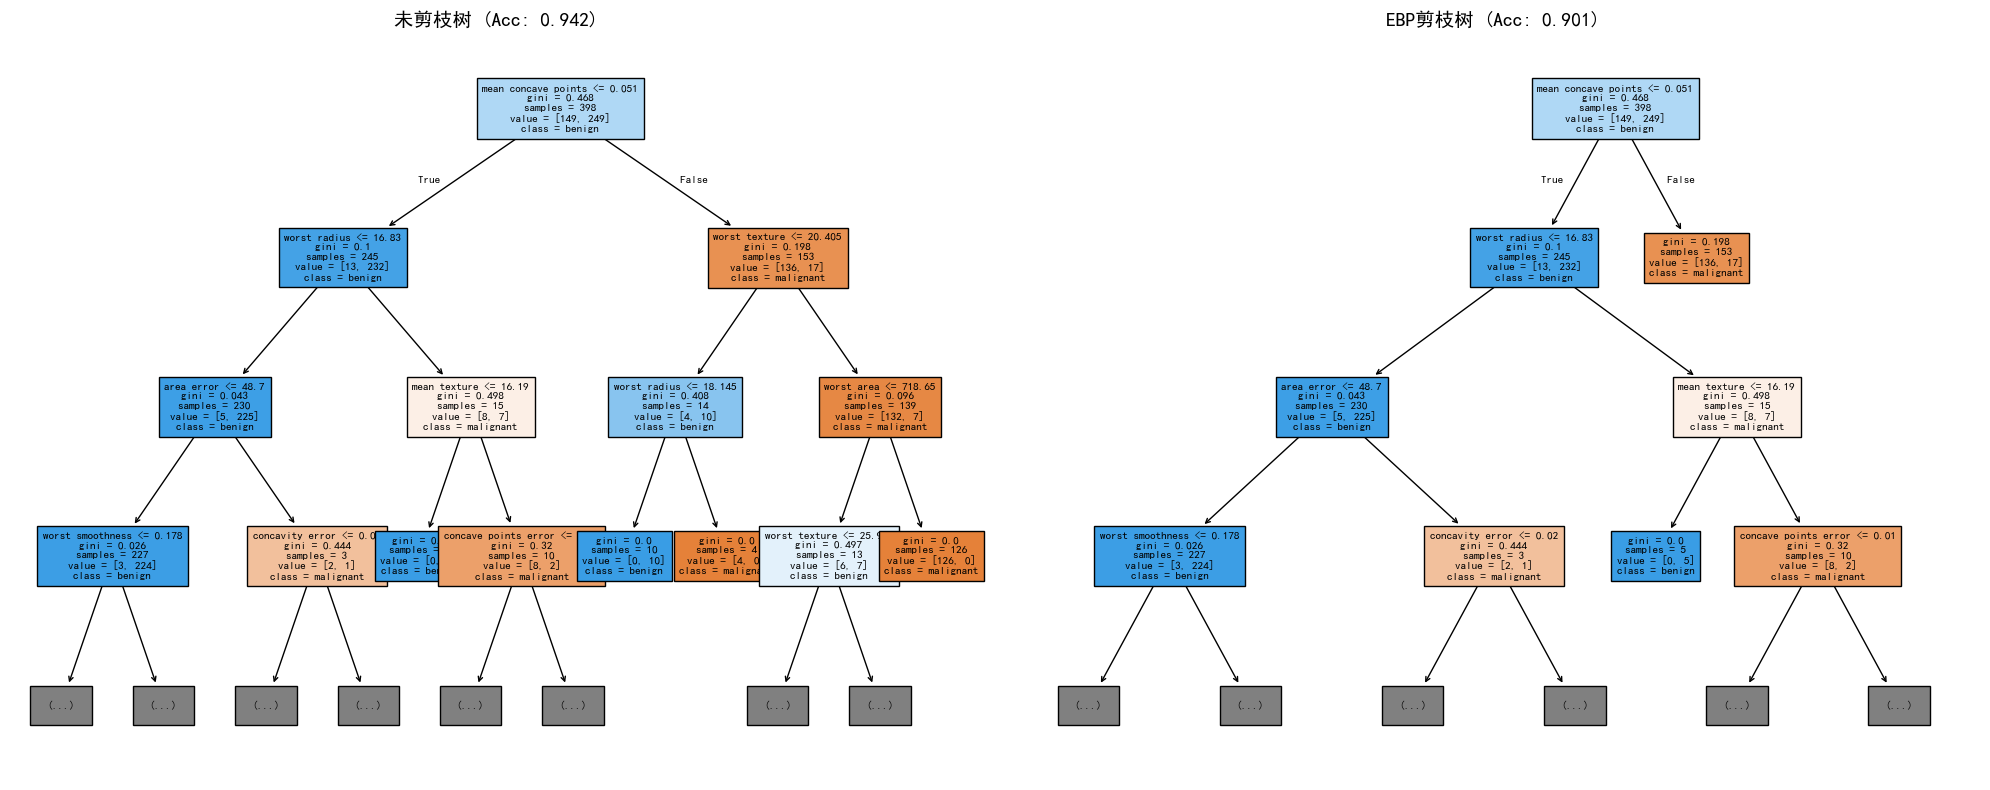


剪枝详情 (前5个):
 node_id  leaf_error_est  subtree_error_est  benefit
      26      139.294952         139.632833 0.337882
      22      153.315855         153.620595 0.304740


In [27]:
# ------------------------
# 可视化对比
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 8))  # 创建画布，1行2列

# 绘制未剪枝树
plot_tree(dt_unpruned, ax=axes[0], filled=True, feature_names=data.feature_names,
          class_names=data.target_names, max_depth=3, fontsize=8)
axes[0].set_title(f"未剪枝树 (Acc: {dt_unpruned.score(X_test, y_test):.3f})", fontsize=14)

# 绘制EBP剪枝树
plot_tree(ebp_dt, ax=axes[1], filled=True, feature_names=data.feature_names,
          class_names=data.target_names, max_depth=3, fontsize=8)
# 这里title使用了ebp_dt的准确率
axes[1].set_title(f"EBP剪枝树 (Acc: {ebp_dt.score(X_test, y_test):.3f})", fontsize=14)

plt.tight_layout()  # 调整布局防止重叠
plt.savefig('ebp_comparison_optimized.png')  # 保存图片
print("\n图表已保存为 'ebp_comparison_optimized.png'")  # 提示保存成功
plt.show()  # 显示图表

# ------------------------
# 剪枝详细信息展示
# ------------------------
if len(ebp_dt.pruning_stats) > 0:  # 如果有剪枝发生
    print("\n剪枝详情 (前5个):")  # 打印标题
    df_stats = pd.DataFrame(ebp_dt.pruning_stats)  # 将统计列表转换为DataFrame
    print(df_stats.head(5).to_string(index=False))  # 打印前5行，不显示索引